# PC LAB 6 - Group 4 - Sofia Michael Yash Omar

Time spent: 20 hours

Difficulty: 6/10

## Library Imports

In [ ]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score, accuracy_score, average_precision_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.feature_selection import RFE, RFECV
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, roc_auc_score
from sklearn import metrics
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
import xgboost as xgb

## Task 1 - EDA

In [2]:
df = pd.read_csv('Data_PCLab5_Private/Data_PCLab5_train_test.csv')

In [150]:
test = pd.read_csv('Data_PCLab5_Private/Data_PCLab5_pred.csv')

In [3]:
df

,industry,credit_score,year,turnover,year_creation,total_actif,id,total_asset,net_total_asset,margin,...,stable_debt,financial_debt,tot_debt,investment,ppe,intangible,ppent,sales,capital,nbemp
0,47,3,2016,1.793,2006.0,1951,1479243776825,2120.0,1951.0,0.588608,...,335.0,336.0,560.0,7.0,217.0,0,380.0,1793.0,1588.0,4.0
1,68,6,2012,0.037,2003.0,365,1353691776396,530.0,365.0,0.000000,...,0.0,592.0,603.0,0.0,508.0,0,673.0,37.0,508.0,0.0
2,47,5+,2016,1.899,2004.0,1730,1359587200964,1805.0,1730.0,0.000000,...,180.0,206.0,423.0,0.0,76.0,0,151.0,1899.0,1373.0,0.0
3,55,4,2004,1.085,2000.0,1945,1296533120972,2559.0,1945.0,0.000000,...,888.0,1235.0,1499.0,13.0,1587.0,0,2061.0,1085.0,2018.0,3.0
4,59,5+,2012,1.350,1996.0,2372,1229382656899,3020.0,2372.0,0.250000,...,57.0,320.0,915.0,26.0,113.0,0,197.0,1350.0,2093.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,47,4+,2008,2.177,1981.0,1115,968708416945,1265.0,1115.0,0.000000,...,25.0,216.0,777.0,0.0,193.0,0,334.0,2177.0,270.0,15.0
49996,71,4+,2016,2.771,2000.0,2862,1295590912908,3315.0,2862.0,-0.203240,...,585.0,949.0,1548.0,278.0,342.0,0,407.0,2771.0,520.0,9.0
49997,68,4+,2007,0.126,1998.0,148,1245545600914,183.0,148.0,0.916667,...,0.0,66.0,73.0,0.0,0.0,0,0.0,126.0,35.0,0.0
49998,46,5,2016,9.670,1991.0,5807,1148055808983,6314.0,5807.0,-0.011514,...,44.0,44.0,4715.0,7.0,190.0,0,339.0,9670.0,573.0,35.0


### Columns Description

- **industry**: Industry sector of the company (encoded as integers)
- **credit_score**: Credit score  of the company assigned
- **year**: Year of the record
- **turnover**: sales/1000
- **year_creation**: Year of company creation
- **total_actif**: net total assets for all but ~200 entries
- **id**: unique identifier of the company
- **total_asset**: total assets of the company
- **net_total_assets**: net total assets of the company
- **margin**: profit margin
- **wcr**: working capital requirement (current assets - current liabilities)
- **sfc**: ?? stock flow consistency?? short term financial commitments?? stable finance capital??
- **bank_debt**: bank debt
- **bank_debt_lt**: long-term bank debt
- **other_debt**: other debt
- **tot_debt1** & **tot_debt2**: total debt (two different calculations)??, usually tot_debt1 > tot_debt2
- **equity1** & **equity2**: equity (two different calculations)??, usually equity1 > equity2
- **stable_debt**: less risky debt, possibly bank debt and other stable financing sources
- **financial_debt**: financial debt, interest bearing??
- **tot_debt**: total debt of the company
- **investment**: value of investments made by the company
- **ppe**: property, plant, and equipment
- **intangibles**: intangible assets
- **ppent**: Generally larger than ppe
- **sales**: sales revenue
- **capital**: capital of the company
- **nbemp**: number of employees

In [4]:
list(df.columns)

['industry',
 'credit_score',
 'year',
 'turnover',
 'year_creation',
 'total_actif',
 'id',
 'total_asset',
 'net_total_asset',
 'margin',
 'wcr',
 'sfc',
 'bank_debt',
 'bank_debt_lt',
 'other_debt',
 'tot_debt1',
 'tot_debt2',
 'equity1',
 'equity2',
 'stable_debt',
 'financial_debt',
 'tot_debt',
 'investment',
 'ppe',
 'intangible',
 'ppent',
 'sales',
 'capital',
 'nbemp']

#### Understanding stable debt

In [5]:
df[['bank_debt',
 'bank_debt_lt',
 'other_debt',
 'tot_debt1',
 'tot_debt2',
 'stable_debt',
 'financial_debt',
 'tot_debt']]

,bank_debt,bank_debt_lt,other_debt,tot_debt1,tot_debt2,stable_debt,financial_debt,tot_debt
0,335.0,335.0,0.0,560.0,499.0,335.0,336.0,560.0
1,0.0,0.0,0.0,604.0,593.0,0.0,592.0,603.0
2,180.0,180.0,0.0,424.0,373.0,180.0,206.0,423.0
3,888.0,888.0,0.0,1499.0,1390.0,888.0,1235.0,1499.0
4,57.0,57.0,0.0,915.0,663.0,57.0,320.0,915.0
...,...,...,...,...,...,...,...,...
49995,25.0,25.0,0.0,777.0,689.0,25.0,216.0,777.0
49996,585.0,582.0,0.0,1548.0,1400.0,585.0,949.0,1548.0
49997,0.0,0.0,0.0,73.0,69.0,0.0,66.0,73.0
49998,44.0,0.0,0.0,4716.0,1897.0,44.0,44.0,4715.0


In [6]:
df["other_debt"].value_counts()

other_debt
0.0        49457
1.0           43
2.0           12
3.0            8
5.0            8
           ...  
87816.0        1
59.0           1
267.0          1
6830.0         1
8870.0         1
Name: count, Length: 385, dtype: int64

Given that we notices that other_debt seems to be zero most of the times we decided to investigate it further. It turns out that we only have 543 rows out of the 50k that have a value for other_debt.

Seems like stable debt is similar to bank debt. Further investigation is needed.

In [7]:
test = df[df['bank_debt'] != df['stable_debt']][['bank_debt',
 'bank_debt_lt',
 'other_debt',
 'tot_debt1',
 'tot_debt2',
 'stable_debt',
 'financial_debt',
 'tot_debt']]
test

,bank_debt,bank_debt_lt,other_debt,tot_debt1,tot_debt2,stable_debt,financial_debt,tot_debt
52,11142.0,11142.0,860.0,12126.0,12110.0,12002.0,12002.0,12126.0
55,8314.0,8309.0,3400.0,16399.0,15658.0,11714.0,14643.0,16398.0
181,7192.0,7187.0,2315.0,12290.0,10350.0,9507.0,10197.0,12291.0
182,606.0,606.0,494.0,1206.0,1166.0,1100.0,1161.0,1206.0
437,262.0,262.0,1.0,2481.0,1991.0,263.0,1299.0,2481.0
...,...,...,...,...,...,...,...,...
49884,0.0,0.0,44.0,328.0,215.0,44.0,183.0,328.0
49921,4485.0,4485.0,8870.0,14292.0,13872.0,13355.0,13815.0,14292.0
49950,6259.0,4586.0,500.0,9975.0,9295.0,6759.0,8565.0,9975.0
49966,408.0,408.0,6.0,912.0,601.0,414.0,490.0,998.0


In [8]:
test["other_debt"].isna().sum()

0

We can see that we have exactly 543 rows where the bank debt is not equal to stable debt. As we remembered the date from the other_debt we hypothesised, that these 543 coincide. As the code above shows we see that our intuition was right. 

In [9]:
df[df['bank_debt'] > df['stable_debt']][['bank_debt',
 'bank_debt_lt',
 'other_debt',
 'tot_debt1',
 'tot_debt2',
 'stable_debt',
 'financial_debt',
 'tot_debt', 'investment']]

,bank_debt,bank_debt_lt,other_debt,tot_debt1,tot_debt2,stable_debt,financial_debt,tot_debt,investment


When comparing, we see that stable debt is always greater than or equal to bank debt. This suggests that stable debt might be a broader category that includes bank debt along with other forms of stable financing.

In [10]:
df[df['financial_debt'] < df['stable_debt']][['bank_debt',
 'bank_debt_lt',
 'other_debt',
 'tot_debt1',
 'tot_debt2',
 'stable_debt',
 'financial_debt',
 'tot_debt', 'investment']]

,bank_debt,bank_debt_lt,other_debt,tot_debt1,tot_debt2,stable_debt,financial_debt,tot_debt,investment


In [11]:
df[df['financial_debt'] >= df['stable_debt']][['bank_debt',
 'bank_debt_lt',
 'other_debt',
 'tot_debt1',
 'tot_debt2',
 'stable_debt',
 'financial_debt',
 'tot_debt', 'investment']]

,bank_debt,bank_debt_lt,other_debt,tot_debt1,tot_debt2,stable_debt,financial_debt,tot_debt,investment
0,335.0,335.0,0.0,560.0,499.0,335.0,336.0,560.0,7.0
1,0.0,0.0,0.0,604.0,593.0,0.0,592.0,603.0,0.0
2,180.0,180.0,0.0,424.0,373.0,180.0,206.0,423.0,0.0
3,888.0,888.0,0.0,1499.0,1390.0,888.0,1235.0,1499.0,13.0
4,57.0,57.0,0.0,915.0,663.0,57.0,320.0,915.0,26.0
...,...,...,...,...,...,...,...,...,...
49995,25.0,25.0,0.0,777.0,689.0,25.0,216.0,777.0,0.0
49996,585.0,582.0,0.0,1548.0,1400.0,585.0,949.0,1548.0,278.0
49997,0.0,0.0,0.0,73.0,69.0,0.0,66.0,73.0,0.0
49998,44.0,0.0,0.0,4716.0,1897.0,44.0,44.0,4715.0,7.0


Similarly, financial debt is always greater than or equal to stable debt, indicating that financial debt encompasses stable debt along with other types of financial obligations. We can assume that stable debt is financial debt that is more predictable and less risky, composed of bank debt and possibly other stable financing sources. 

In [12]:
sum_debts = df['bank_debt'] + df['other_debt']
match_mask = np.isclose(sum_debts, df['stable_debt'], rtol=1e-9, atol=1e-6)

n_total = len(df)
n_match = int(match_mask.sum())
n_diff = n_total - n_match

print(f"Total rows: {n_total}")
print(f"Rows where bank_debt + other_debt == stable_debt (within tolerance): {n_match}")
print(f"Rows where they differ: {n_diff}")

diff_df = df.loc[~match_mask, ['bank_debt', 'other_debt', 'stable_debt']].copy()
diff_df['sum_bank_other'] = diff_df['bank_debt'] + diff_df['other_debt']
diff_df['diff'] = diff_df['sum_bank_other'] - diff_df['stable_debt']

print("\nFirst 10 rows where they differ:")
print(diff_df.head(10))

if 'test' in globals():
    test_mask = ~np.isclose(test['bank_debt'] + test['other_debt'], test['stable_debt'], rtol=1e-9, atol=1e-6)
    print(f"\nIn 'test' subset (size {len(test)}), rows differing: {int(test_mask.sum())}")

Total rows: 50000
Rows where bank_debt + other_debt == stable_debt (within tolerance): 50000
Rows where they differ: 0

First 10 rows where they differ:
Empty DataFrame
Columns: [bank_debt, other_debt, stable_debt, sum_bank_other, diff]
Index: []

In 'test' subset (size 543), rows differing: 0


We can also see that the stable debt turns out to be the sum of bank_debt and other_debt.

#### Understanding turnover

In [13]:
df[['turnover', 'sales', 'total_asset', 'total_actif']]

,turnover,sales,total_asset,total_actif
0,1.793,1793.0,2120.0,1951
1,0.037,37.0,530.0,365
2,1.899,1899.0,1805.0,1730
3,1.085,1085.0,2559.0,1945
4,1.350,1350.0,3020.0,2372
...,...,...,...,...
49995,2.177,2177.0,1265.0,1115
49996,2.771,2771.0,3315.0,2862
49997,0.126,126.0,183.0,148
49998,9.670,9670.0,6314.0,5807


In [14]:
df[df['turnover']!= df['sales']/1000][['turnover', 'sales', 'total_asset', 'total_actif']]

,turnover,sales,total_asset,total_actif
8,32.774,32773.0,46318.0,21309
26,110.689,110688.0,93688.0,50147
53,14.197,14196.0,22387.0,16546
74,1.368,1369.0,978.0,926
93,1.109,1108.0,733.0,612
...,...,...,...,...
49937,1.361,1362.0,2585.0,1370
49944,1.999,2000.0,1254.0,1091
49978,18.026,18025.0,21575.0,18975
49983,13.661,13660.0,5728.0,4282


In [15]:
mask = (df['turnover'] - df['sales']/1000).abs() > 1
df[mask][['turnover', 'sales', 'total_asset', 'total_actif']]

,turnover,sales,total_asset,total_actif


We notice that turnover seems to be closely related to sales, specifically turnover appears to be sales divided by 1000. (+/-1 tolerance)

#### Understanding total_asset and total_actif

In [16]:
df[['total_asset', 'total_actif', 'net_total_asset']]

,total_asset,total_actif,net_total_asset
0,2120.0,1951,1951.0
1,530.0,365,365.0
2,1805.0,1730,1730.0
3,2559.0,1945,1945.0
4,3020.0,2372,2372.0
...,...,...,...
49995,1265.0,1115,1115.0
49996,3315.0,2862,2862.0
49997,183.0,148,148.0
49998,6314.0,5807,5807.0


In [17]:
df[df['total_actif'] != df['net_total_asset']][['total_asset', 'total_actif', 'net_total_asset', 'tot_debt', 'financial_debt']]

,total_asset,total_actif,net_total_asset,tot_debt,financial_debt
160,1078.0,905,855.0,1803.0,32.0
891,161.0,220,160.0,216.0,196.0
1059,4035.0,4045,4032.0,401.0,270.0
1228,29730.0,11224,10588.0,7667.0,5797.0
1365,866.0,488,482.0,428.0,0.0
...,...,...,...,...,...
48686,405.0,394,386.0,631.0,553.0
48759,263.0,264,263.0,25.0,10.0
49021,246.0,258,239.0,208.0,152.0
49089,988.0,816,794.0,634.0,375.0


We can see that net_total_asset is similar to total_actif for most entries. However, there are some discrepancies where total_actif does not equal net_total_asset. We are not able to reach a conclusion for why this is the case yet.

#### Understanding ppe and ppent

In [18]:
df[(df['ppe'] >= df['ppent']) & (df['ppe'] != 0)][['ppe', 'ppent']]

,ppe,ppent
253,2605.0,2605.0
267,1.0,1.0
378,107.0,107.0
454,36.0,36.0
465,1068.0,1068.0
...,...,...
49749,29.0,29.0
49757,5058.0,5018.0
49887,29.0,29.0
49958,15154.0,15154.0


In [19]:
df[(df['ppe'] < df['ppent']) & (df['ppe'] != 0)][['ppe', 'ppent']]

,ppe,ppent
0,217.0,380.0
1,508.0,673.0
2,76.0,151.0
3,1587.0,2061.0
4,113.0,197.0
...,...,...
49994,29704.0,49675.0
49995,193.0,334.0
49996,342.0,407.0
49998,190.0,339.0


We see that ppent is generally greater than or equal to ppe. This suggests that ppent might represent a broader category of assets that includes property, plant, and equipment (ppe) along with other related assets. Further investigation is needed to confirm this hypothesis.

#### Understanding tot_debt1, tot_debt2, equity1, equity2

In [20]:
df[['bank_debt', 'tot_debt1', 'tot_debt2', 'other_debt', 'sfc', 'tot_debt', 'financial_debt', 'stable_debt','equity1', 'equity2']]

,bank_debt,tot_debt1,tot_debt2,other_debt,sfc,tot_debt,financial_debt,stable_debt,equity1,equity2
0,335.0,560.0,499.0,0.0,198.00,560.0,336.0,335.0,1390.0,0.0
1,0.0,604.0,593.0,0.0,0.00,603.0,592.0,0.0,-239.0,0.0
2,180.0,424.0,373.0,0.0,0.00,423.0,206.0,180.0,1306.0,0.0
3,888.0,1499.0,1390.0,0.0,0.00,1499.0,1235.0,888.0,431.0,0.0
4,57.0,915.0,663.0,0.0,223.00,915.0,320.0,57.0,1456.0,0.0
...,...,...,...,...,...,...,...,...,...,...
49995,25.0,777.0,689.0,0.0,0.00,777.0,216.0,25.0,338.0,0.0
49996,585.0,1548.0,1400.0,0.0,1094.00,1548.0,949.0,585.0,1314.0,0.0
49997,0.0,73.0,69.0,0.0,96.51,73.0,66.0,0.0,75.0,0.0
49998,44.0,4716.0,1897.0,0.0,375.00,4715.0,44.0,44.0,1011.0,0.0


In [21]:
df[(df['tot_debt2'] - df['tot_debt1']) > 1][['bank_debt', 'tot_debt1', 'tot_debt2', 'other_debt', 'sfc', 'tot_debt', 'financial_debt', 'stable_debt','equity1', 'equity2']]

,bank_debt,tot_debt1,tot_debt2,other_debt,sfc,tot_debt,financial_debt,stable_debt,equity1,equity2
38683,0.0,517.0,521.0,0.0,1072.0,521.0,515.0,0.0,1047.0,0.0
41040,0.0,16.0,19.0,0.0,-5.0,19.0,11.0,0.0,162.0,0.0


In [22]:
df[df['tot_debt2'] < df['tot_debt1']][['bank_debt', 'tot_debt1', 'tot_debt2', 'other_debt', 'sfc', 'tot_debt', 'financial_debt', 'stable_debt','equity1', 'equity2']]

,bank_debt,tot_debt1,tot_debt2,other_debt,sfc,tot_debt,financial_debt,stable_debt,equity1,equity2
0,335.0,560.0,499.0,0.0,198.00,560.0,336.0,335.0,1390.0,0.0
1,0.0,604.0,593.0,0.0,0.00,603.0,592.0,0.0,-239.0,0.0
2,180.0,424.0,373.0,0.0,0.00,423.0,206.0,180.0,1306.0,0.0
3,888.0,1499.0,1390.0,0.0,0.00,1499.0,1235.0,888.0,431.0,0.0
4,57.0,915.0,663.0,0.0,223.00,915.0,320.0,57.0,1456.0,0.0
...,...,...,...,...,...,...,...,...,...,...
49995,25.0,777.0,689.0,0.0,0.00,777.0,216.0,25.0,338.0,0.0
49996,585.0,1548.0,1400.0,0.0,1094.00,1548.0,949.0,585.0,1314.0,0.0
49997,0.0,73.0,69.0,0.0,96.51,73.0,66.0,0.0,75.0,0.0
49998,44.0,4716.0,1897.0,0.0,375.00,4715.0,44.0,44.0,1011.0,0.0


We see that in most cases, tot_debt1 is greater than tot_debt2. This suggests that tot_debt1 might include additional components or calculations that result in a higher value compared to tot_debt2.

In [23]:
df[(df['tot_debt'] - df['tot_debt1']).abs() > 1][['bank_debt', 'tot_debt1', 'tot_debt2', 'other_debt', 'sfc', 'tot_debt', 'financial_debt', 'stable_debt','equity1', 'equity2']]

,bank_debt,tot_debt1,tot_debt2,other_debt,sfc,tot_debt,financial_debt,stable_debt,equity1,equity2
48,146.0,333.0,278.0,0.0,48.00,335.0,146.0,146.0,35.0,0.0
86,257.0,1551.0,664.0,0.0,-56.47,1549.0,259.0,257.0,-250.0,0.0
90,0.0,73.0,0.0,0.0,48.00,70.0,0.0,0.0,-69.0,0.0
104,926.0,1007.0,970.0,0.0,114.00,1005.0,965.0,926.0,343.0,0.0
113,2784.0,9514.0,7530.0,0.0,36.26,9538.0,5420.0,2784.0,5035.0,6270.0
...,...,...,...,...,...,...,...,...,...,...
49919,2458.0,8633.0,2812.0,0.0,-708.00,10374.0,2458.0,2458.0,-6328.0,217.0
49944,2.0,327.0,268.0,0.0,37.09,333.0,33.0,2.0,744.0,0.0
49946,2809.0,20665.0,17143.0,0.0,-7525.75,20717.0,2944.0,2809.0,28327.0,0.0
49956,1396.0,8072.0,6257.0,0.0,-1136.00,8075.0,3589.0,1396.0,-3029.0,0.0


In [24]:
df[df['tot_debt'] < df['tot_debt1']][['bank_debt', 'tot_debt1', 'tot_debt2', 'other_debt', 'sfc', 'tot_debt', 'financial_debt', 'stable_debt','equity1', 'equity2']]

,bank_debt,tot_debt1,tot_debt2,other_debt,sfc,tot_debt,financial_debt,stable_debt,equity1,equity2
1,0.0,604.0,593.0,0.0,0.00,603.0,592.0,0.0,-239.0,0.0
2,180.0,424.0,373.0,0.0,0.00,423.0,206.0,180.0,1306.0,0.0
5,138.0,1019.0,890.0,0.0,274.96,1018.0,238.0,138.0,1246.0,0.0
8,0.0,5963.0,2830.0,0.0,716.00,5962.0,0.0,0.0,13721.0,0.0
11,296.0,1050.0,782.0,0.0,150.94,1049.0,580.0,296.0,598.0,0.0
...,...,...,...,...,...,...,...,...,...,...
49978,426.0,11324.0,6769.0,0.0,1396.97,11323.0,2230.0,426.0,6439.0,0.0
49985,67.0,538.0,353.0,0.0,98.87,537.0,67.0,67.0,225.0,0.0
49986,0.0,849.0,297.0,0.0,628.00,848.0,0.0,0.0,468.0,0.0
49988,87.0,593.0,109.0,0.0,127.00,592.0,87.0,87.0,236.0,0.0


In [25]:
df[((df['tot_debt'] - df['tot_debt1']).abs() > 1) & (df['tot_debt1'] > df['tot_debt'])][['bank_debt', 'tot_debt1', 'tot_debt2', 'other_debt', 'sfc', 'tot_debt', 'financial_debt', 'stable_debt','equity1', 'equity2']]

,bank_debt,tot_debt1,tot_debt2,other_debt,sfc,tot_debt,financial_debt,stable_debt,equity1,equity2
86,257.0,1551.0,664.0,0.0,-56.47,1549.0,259.0,257.0,-250.0,0.0
90,0.0,73.0,0.0,0.0,48.00,70.0,0.0,0.0,-69.0,0.0
104,926.0,1007.0,970.0,0.0,114.00,1005.0,965.0,926.0,343.0,0.0
266,80520.0,235705.0,228426.0,0.0,2818.00,235703.0,228345.0,80520.0,-21938.0,0.0
338,0.0,243.0,110.0,0.0,0.00,241.0,17.0,0.0,509.0,0.0
...,...,...,...,...,...,...,...,...,...,...
49674,0.0,88433.0,6720.0,0.0,-306.00,88431.0,4811.0,0.0,-830.0,0.0
49818,280.0,822.0,516.0,0.0,0.00,820.0,335.0,280.0,119.0,0.0
49826,139.0,520.0,407.0,0.0,0.00,518.0,328.0,139.0,109.0,0.0
49891,34.0,276.0,242.0,0.0,21.22,274.0,71.0,34.0,77.0,0.0


It is difficult to ascertain the relationship between tot_debt1, tot_debt2 and tot_debt. We will treat them as three different calculations of total debt for now. We will also assume the are heavily correlated.

In [26]:
df[['equity1', 'equity2']]

,equity1,equity2
0,1390.0,0.0
1,-239.0,0.0
2,1306.0,0.0
3,431.0,0.0
4,1456.0,0.0
...,...,...
49995,338.0,0.0
49996,1314.0,0.0
49997,75.0,0.0
49998,1011.0,0.0


In [27]:
df[df['equity2'] != 0][['equity1', 'equity2']]

,equity1,equity2
53,6937.0,60.0
56,243.0,88.0
113,5035.0,6270.0
216,-7620.0,193.0
431,242.0,30.0
...,...,...
49682,-12.0,136.0
49819,5772.0,2250.0
49870,884.0,9.0
49876,12.0,322.0


In [28]:
df[df['equity2'] > df['equity1']][['equity1', 'equity2']]

,equity1,equity2
1,-239.0,0.0
14,-171.0,0.0
21,-37.0,0.0
25,-159.0,0.0
30,-205.0,0.0
...,...,...
49956,-3029.0,0.0
49969,-4.0,0.0
49981,-411.0,0.0
49982,-67.0,0.0


In [29]:
df[(df['equity2'] > df['equity1']) & (df['equity1'] > 0)][['equity1', 'equity2']]

,equity1,equity2
113,5035.0,6270.0
693,9.0,37.0
1145,27.0,697.0
2979,570.0,673.0
3551,1323.0,2193.0
3609,447.0,935.0
4719,326.0,15726.0
8655,2586.0,3554.0
9299,405.0,447.0
9422,332.0,634.0


In [30]:
df[df['equity1'] > df['equity2']][['equity1', 'equity2']]

,equity1,equity2
0,1390.0,0.0
2,1306.0,0.0
3,431.0,0.0
4,1456.0,0.0
5,1246.0,0.0
...,...,...
49994,19671.0,0.0
49995,338.0,0.0
49996,1314.0,0.0
49997,75.0,0.0


In [31]:
df[(df['equity1'] > df['equity2']) & (df['equity2'] > 0)][['equity1', 'equity2']]

,equity1,equity2
53,6937.0,60.0
56,243.0,88.0
431,242.0,30.0
603,96.0,86.0
678,2116.0,1521.0
...,...,...
49376,4447.0,1006.0
49386,3565.0,126.0
49629,3634.0,100.0
49819,5772.0,2250.0


Once again, it is difficult to ascertain the relationship between equity1 and equity2. We will treat them as two different calculations of equity for now. We will also assume they are heavily correlated.

#### Understanding sfc

In [32]:
df['sfc'].describe()

count    5.000000e+04
mean     7.727525e+02
std      2.785670e+04
min     -1.436060e+05
25%      0.000000e+00
50%      5.700000e+01
75%      1.987900e+02
max      4.822402e+06
Name: sfc, dtype: float64

In [33]:
df['sfc']

0         198.00
1           0.00
2           0.00
3           0.00
4         223.00
          ...   
49995       0.00
49996    1094.00
49997      96.51
49998     375.00
49999    -311.46
Name: sfc, Length: 50000, dtype: float64

In [34]:
df[['sfc','tot_debt']]

,sfc,tot_debt
0,198.00,560.0
1,0.00,603.0
2,0.00,423.0
3,0.00,1499.0
4,223.00,915.0
...,...,...
49995,0.00,777.0
49996,1094.00,1548.0
49997,96.51,73.0
49998,375.00,4715.0


In [35]:
df[['sfc', 'equity1']]

,sfc,equity1
0,198.00,1390.0
1,0.00,-239.0
2,0.00,1306.0
3,0.00,431.0
4,223.00,1456.0
...,...,...
49995,0.00,338.0
49996,1094.00,1314.0
49997,96.51,75.0
49998,375.00,1011.0


In [36]:
df[['sfc', 'wcr']]

,sfc,wcr
0,198.00,-60.0
1,0.00,0.0
2,0.00,0.0
3,0.00,0.0
4,223.00,113.0
...,...,...
49995,0.00,0.0
49996,1094.00,820.0
49997,96.51,143.0
49998,375.00,1094.0


In [37]:
df[(df['sfc'] == 0) & (df['wcr'] != 0)][['sfc', 'wcr']]

,sfc,wcr
347,0.0,-92.0
552,0.0,167.0
751,0.0,1868.0
2191,0.0,-1.0
2255,0.0,6.0
...,...,...
47962,0.0,-18.0
48267,0.0,168.0
48669,0.0,-16.0
48696,0.0,-798.0


Hard to ascertain what sfc represents. It has a wide range of values, including negative values, zeros, and very large positive values. Further investigation is needed to understand its significance and relationship with other financial metrics in the dataset.

### Exploring Cerdit Scoring

In [38]:
df['credit_score'].describe()

count     50000
unique       12
top          5+
freq      12030
Name: credit_score, dtype: object

In [39]:
df['credit_score'].value_counts().sort_index()

credit_score
3       4445
3+      2820
3++     1415
4      10249
4+      6804
5       6477
5+     12030
6       4237
7        514
8        480
9        143
P        386
Name: count, dtype: int64

In [40]:
df['credit_score'].dtype

dtype('O')

In [41]:
# convert 'credit_score' to category, handling strings appropriately
df['credit_score'] = df['credit_score'].astype('category')

In [42]:
df.dtypes

industry              int64
credit_score       category
year                  int64
turnover            float64
year_creation       float64
total_actif           int64
id                    int64
total_asset         float64
net_total_asset     float64
margin              float64
wcr                 float64
sfc                 float64
bank_debt           float64
bank_debt_lt        float64
other_debt          float64
tot_debt1           float64
tot_debt2           float64
equity1             float64
equity2             float64
stable_debt         float64
financial_debt      float64
tot_debt            float64
investment          float64
ppe                 float64
intangible            int64
ppent               float64
sales               float64
capital             float64
nbemp               float64
dtype: object

In [43]:
df['industry'] = df['industry'].astype('category')
df['year'] = pd.to_datetime(df['year'], format='%Y', errors='coerce').dt.year.astype('Int64')
df['year_creation'] = pd.to_datetime(df['year_creation'], format='%Y', errors='coerce').dt.year.astype('Int64')


In [44]:
corr_numeric = df.corr(numeric_only=True)

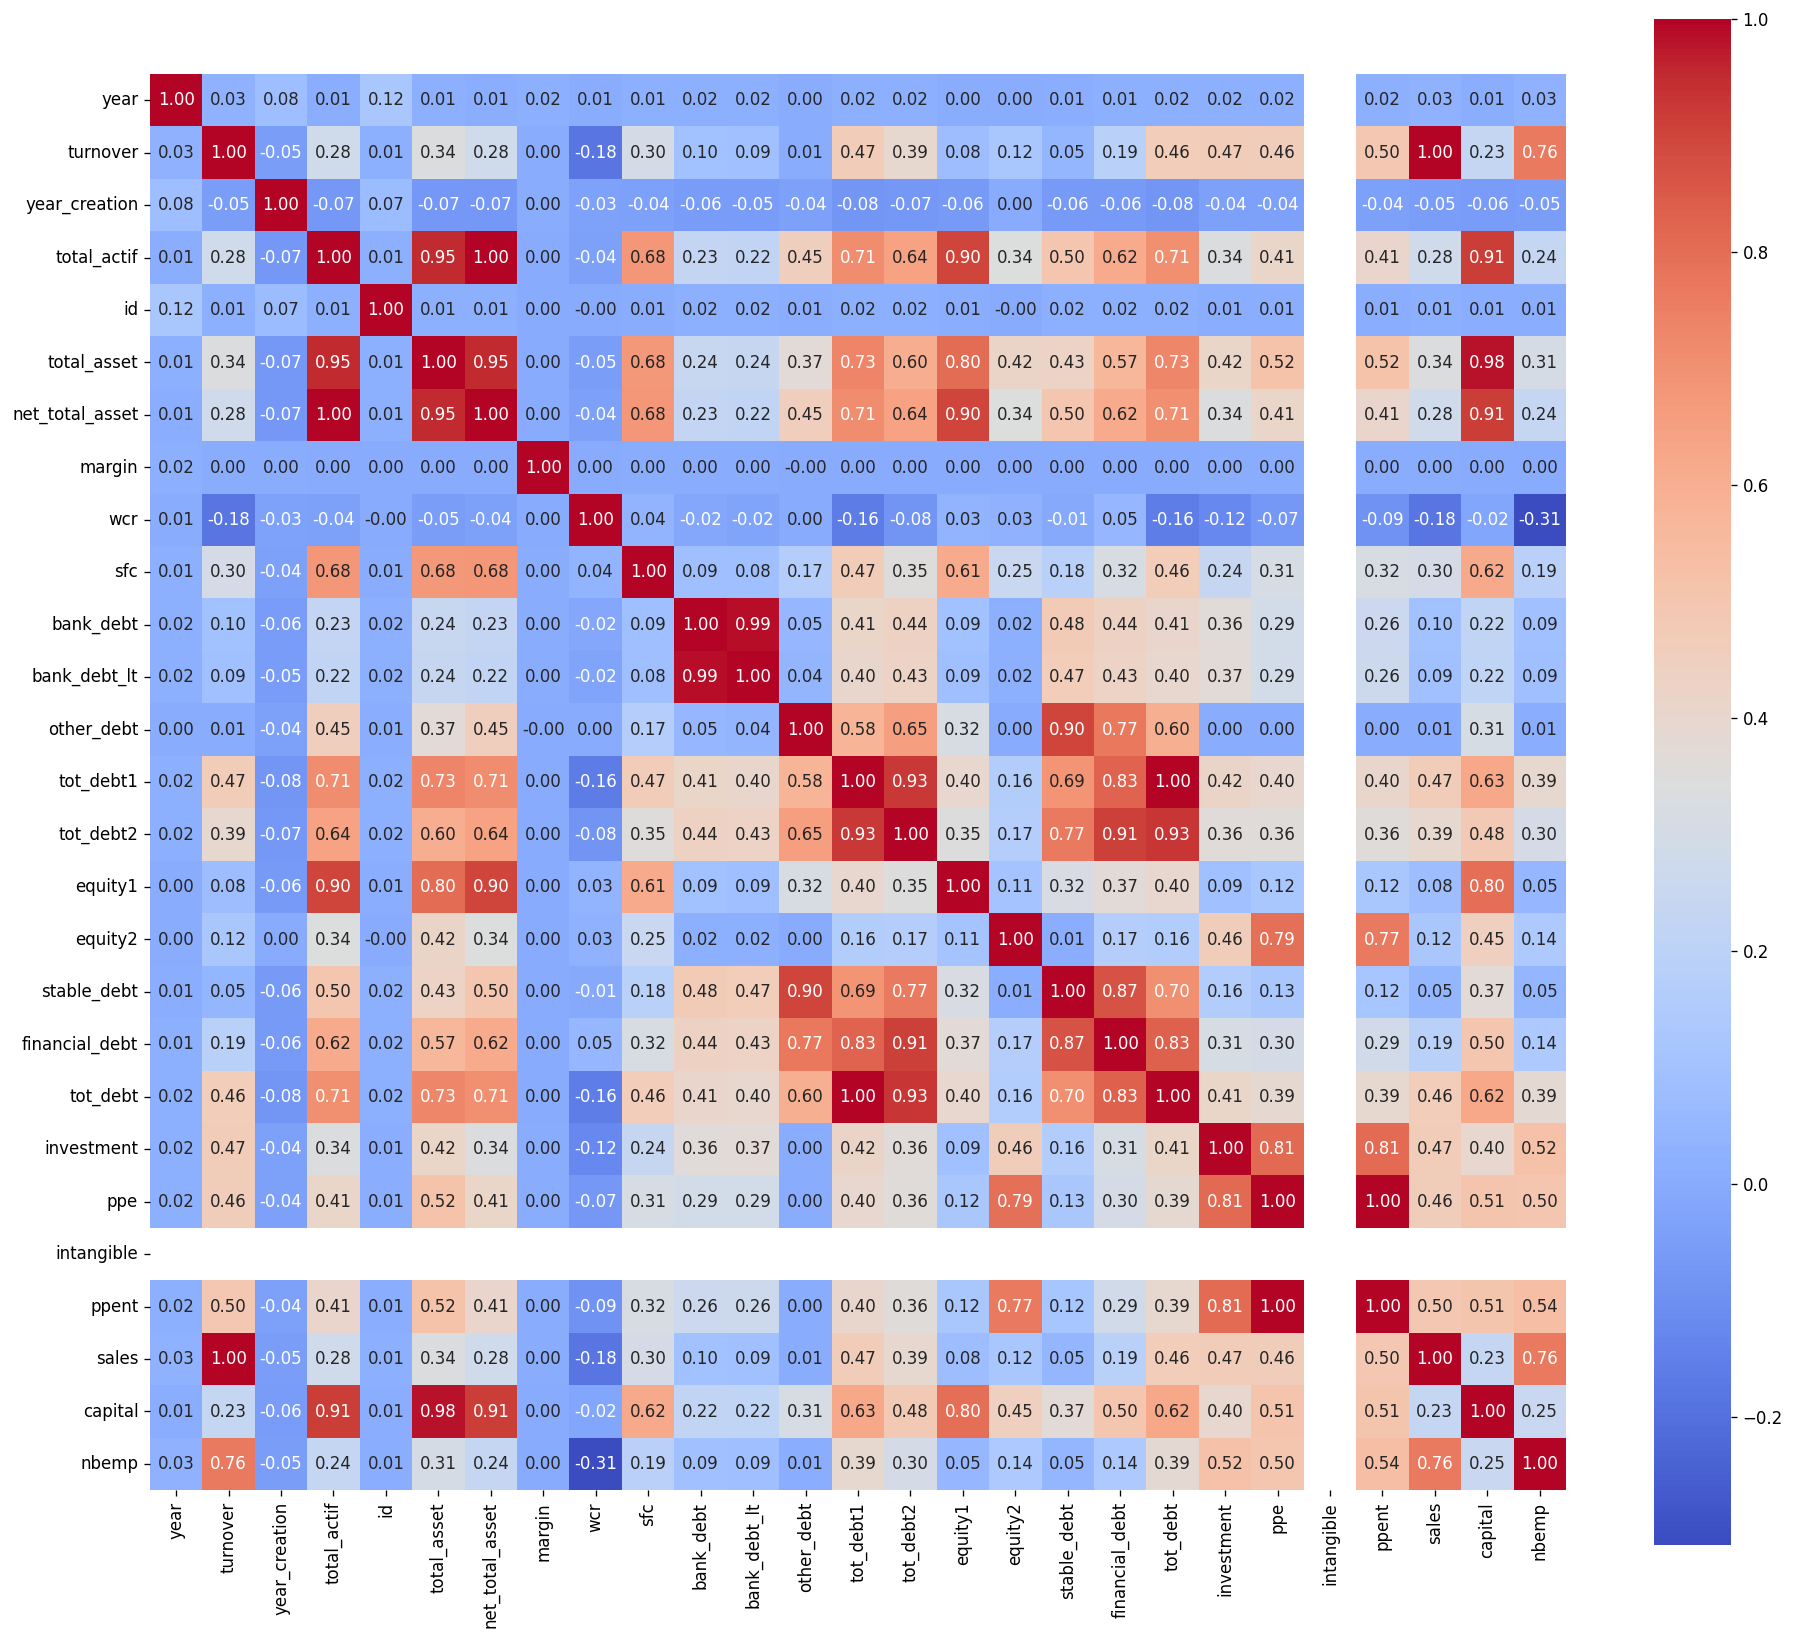

In [45]:
n = corr_numeric.shape[0]
cell = 0.6
plt.figure(figsize=(n*cell, n*cell), dpi=120)
sns.heatmap(corr_numeric, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'shrink':0.8}, square=True)
plt.tight_layout()
plt.show()

In [46]:
df['intangible'].describe()

count    50000.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: intangible, dtype: float64

Intangible contains all missing values.

In [47]:
df.isna().sum()

industry             0
credit_score         0
year                 0
turnover             0
year_creation      154
total_actif          0
id                   0
total_asset          0
net_total_asset      0
margin               0
wcr                  0
sfc                  0
bank_debt            0
bank_debt_lt         0
other_debt           0
tot_debt1            0
tot_debt2            0
equity1              0
equity2              0
stable_debt          0
financial_debt       0
tot_debt             0
investment           0
ppe                  0
intangible           0
ppent                0
sales                0
capital              0
nbemp                0
dtype: int64

In [48]:
# Mutual Information between credit score and the other numerical variables

X = df.drop(columns=['credit_score', 'intangible', 'id', 'year', 'year_creation', 'industry'])
y = df['credit_score']

mutual_info = mutual_info_classif(X, y)

mutual_info = pd.Series(mutual_info)
mutual_info.index = X.columns
mutual_info.sort_values(ascending=False)

equity1            0.241722
sfc                0.110471
margin             0.083246
sales              0.068046
turnover           0.067891
total_actif        0.061036
net_total_asset    0.059153
total_asset        0.049764
investment         0.040691
wcr                0.040383
ppe                0.034499
nbemp              0.032992
ppent              0.030374
capital            0.024443
financial_debt     0.023110
stable_debt        0.021153
bank_debt          0.015731
tot_debt           0.014261
tot_debt2          0.011138
tot_debt1          0.010408
bank_debt_lt       0.010261
equity2            0.000000
other_debt         0.000000
dtype: float64

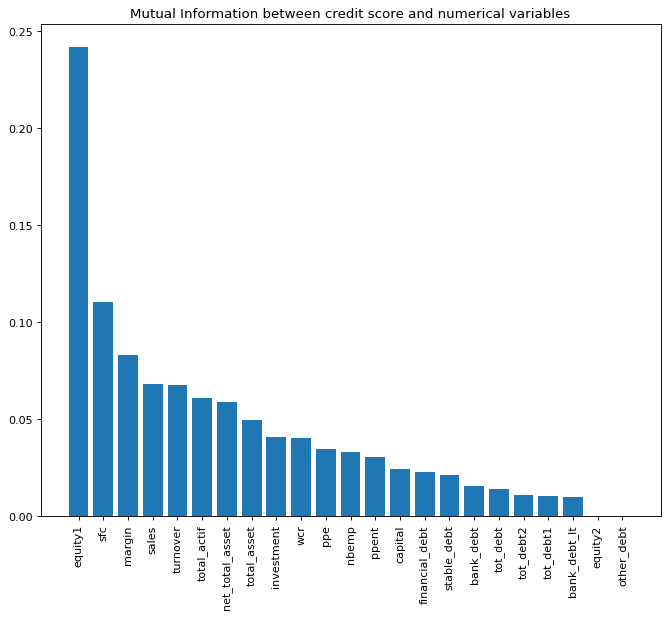

In [49]:
plt.figure(figsize=(10,8), dpi=80)
plt.bar(mutual_info.sort_values(ascending=False).index, mutual_info.sort_values(ascending=False).values)
plt.xticks(rotation=90)
plt.title('Mutual Information between credit score and numerical variables')
plt.show()

We can see that equity has the highest mutual information with credit scores, reaching a value of almost 25%. Following that we have sfc, which we still have not identified, margin and turnover.

<Figure size 1440x720 with 0 Axes>

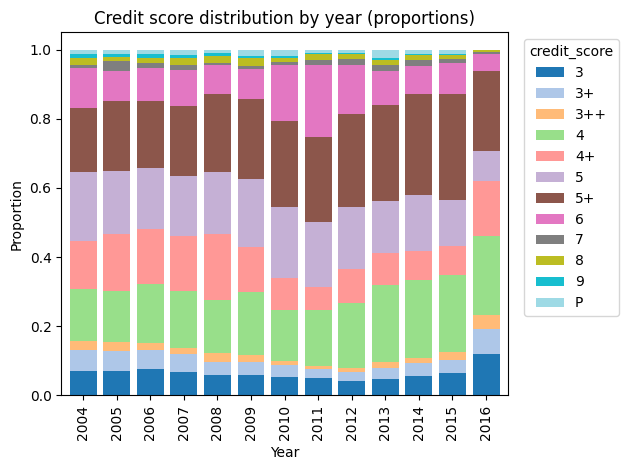

In [50]:
ct = pd.crosstab(df['year'], df['credit_score'])
ct_norm = ct.div(ct.sum(axis=1), axis=0)   # proportions by year

plt.figure(figsize=(12,6), dpi=120)
ct_norm.plot(kind='bar', stacked=True, colormap='tab20', width=0.8, legend=True)
plt.ylabel('Proportion')
plt.xlabel('Year')
plt.title('Credit score distribution by year (proportions)')
plt.legend(title='credit_score', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 2400x1200 with 0 Axes>

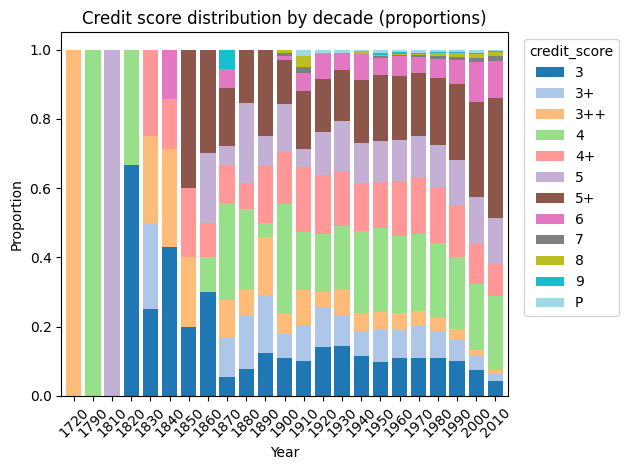

In [51]:
ct = pd.crosstab(df['year_creation'], df['credit_score'])
ct_norm = ct.div(ct.sum(axis=1), axis=0)   # proportions by year

plt.figure(figsize=(20,10), dpi=120)
df_dec = df.dropna(subset=['year_creation']).copy()
df_dec['decade'] = (df_dec['year_creation'].astype(int) // 10) * 10
ct_dec = pd.crosstab(df_dec['decade'], df_dec['credit_score'])
ct_dec_norm = ct_dec.div(ct_dec.sum(axis=1), axis=0).sort_index()
ct_dec_norm.plot(kind='bar', stacked=True, colormap='tab20', width=0.8, legend=True)
plt.xticks(rotation=45)
plt.ylabel('Proportion')
plt.xlabel('Year')
plt.title('Credit score distribution by decade (proportions)')
plt.legend(title='credit_score', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

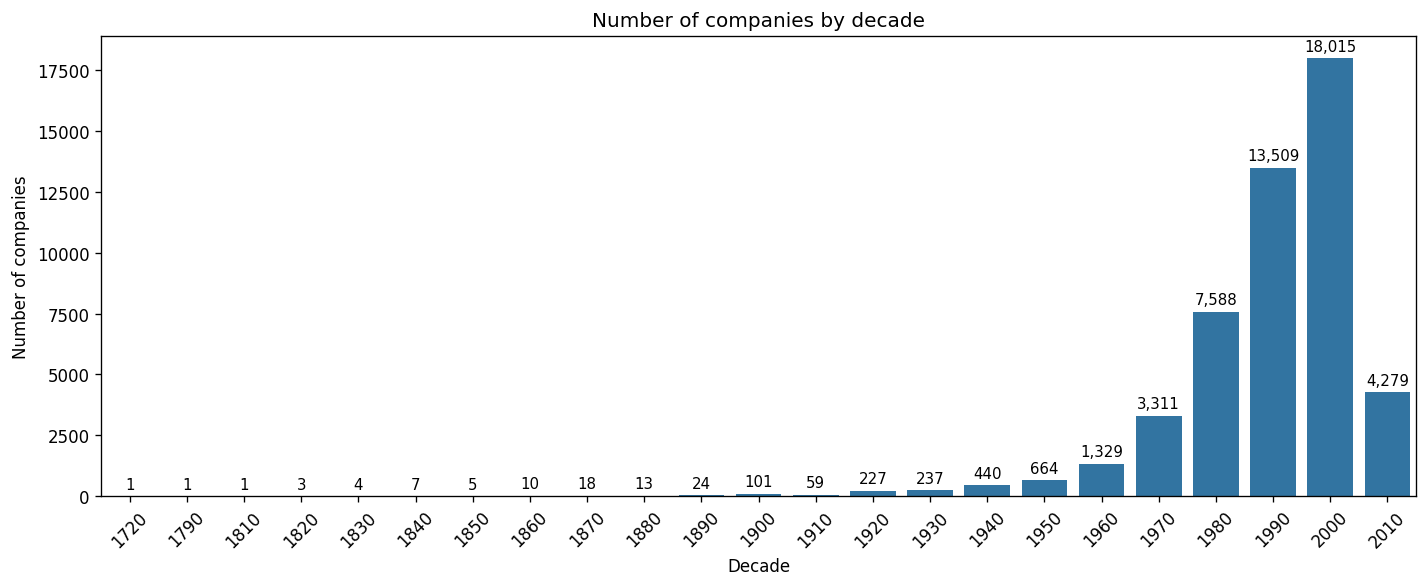

In [52]:
# plot number of companies by decade (uses df_dec defined earlier)
decade_counts = df_dec['decade'].value_counts().sort_index()

plt.figure(figsize=(12,5), dpi=120)
sns.barplot(x=decade_counts.index.astype(int), y=decade_counts.values, color='C0')
plt.xticks(rotation=45)
plt.xlabel('Decade')
plt.ylabel('Number of companies')
plt.title('Number of companies by decade')

# annotate bars with counts
max_val = decade_counts.max()
for i, v in enumerate(decade_counts.values):
    plt.text(i, v + max_val * 0.01, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

It is interesting to see that the number of companies had a very rapid almost exponential growth until 2010. In the 2010s the number of companies came to a quaerer of the decade before. A reason for the low score could be that we have the latest value in 2016. Therefore, the last bar has a smaller timeline that the others. Nevertheless, there seems to be a decrease in the number of companies.

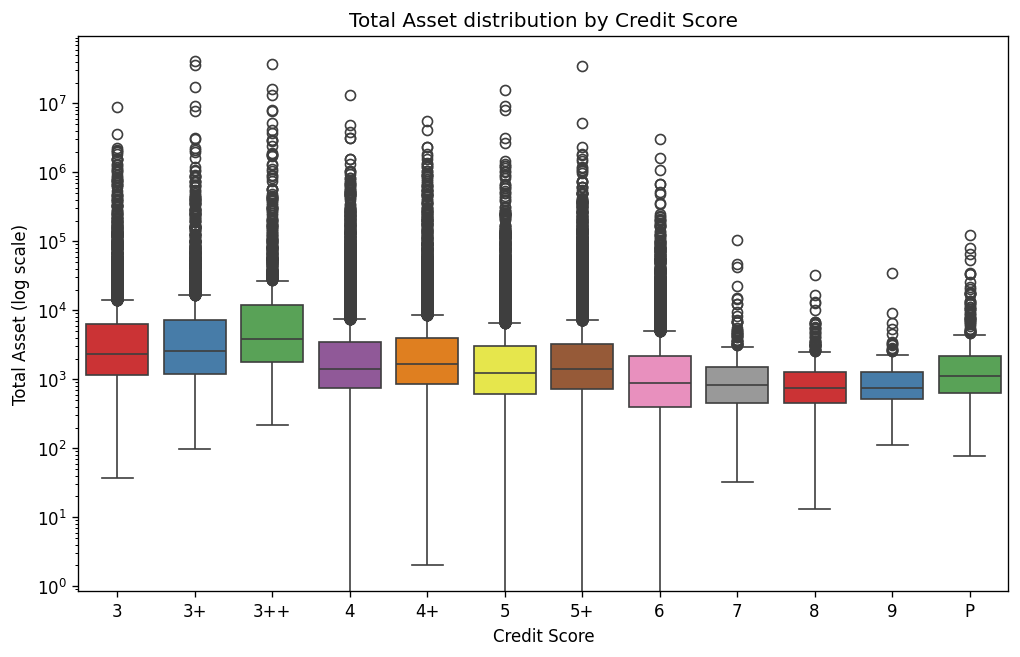

In [53]:
# tot_asset vs credit_score
plt.figure(figsize=(10,6), dpi=120)
sns.boxplot(x='credit_score', y='total_asset', data=df, palette='Set1')
plt.yscale('log')
plt.xlabel('Credit Score')
plt.ylabel('Total Asset (log scale)')
plt.title('Total Asset distribution by Credit Score')
plt.show()

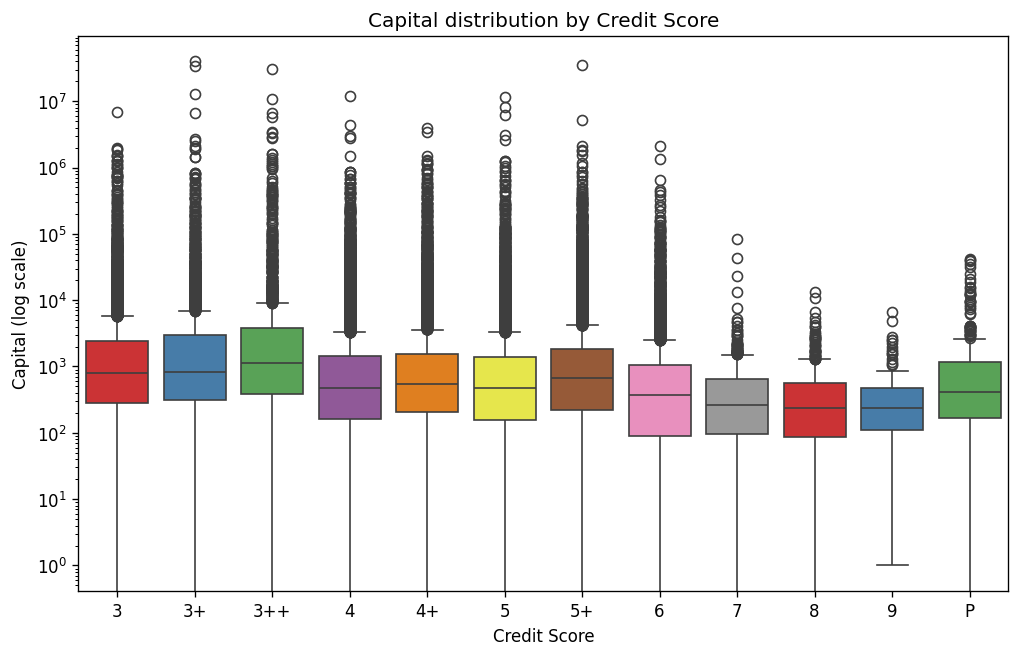

In [54]:
# capital vs credit_score
plt.figure(figsize=(10,6), dpi=120)
sns.boxplot(x='credit_score', y='capital', data=df, palette='Set1')
plt.yscale('log')
plt.xlabel('Credit Score')
plt.ylabel('Capital (log scale)')
plt.title('Capital distribution by Credit Score')
plt.show()

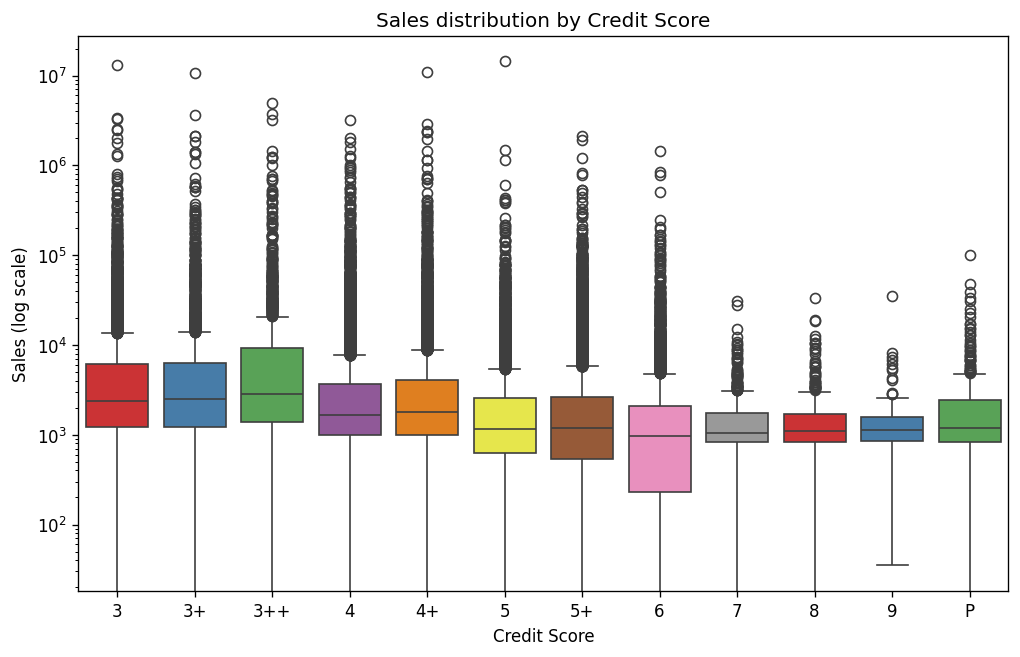

In [55]:
# sales vs credit_score
plt.figure(figsize=(10,6), dpi=120)
sns.boxplot(x='credit_score', y='sales', data=df, palette='Set1')
plt.yscale('log')
plt.xlabel('Credit Score')
plt.ylabel('Sales (log scale)') 
plt.title('Sales distribution by Credit Score')
plt.show()

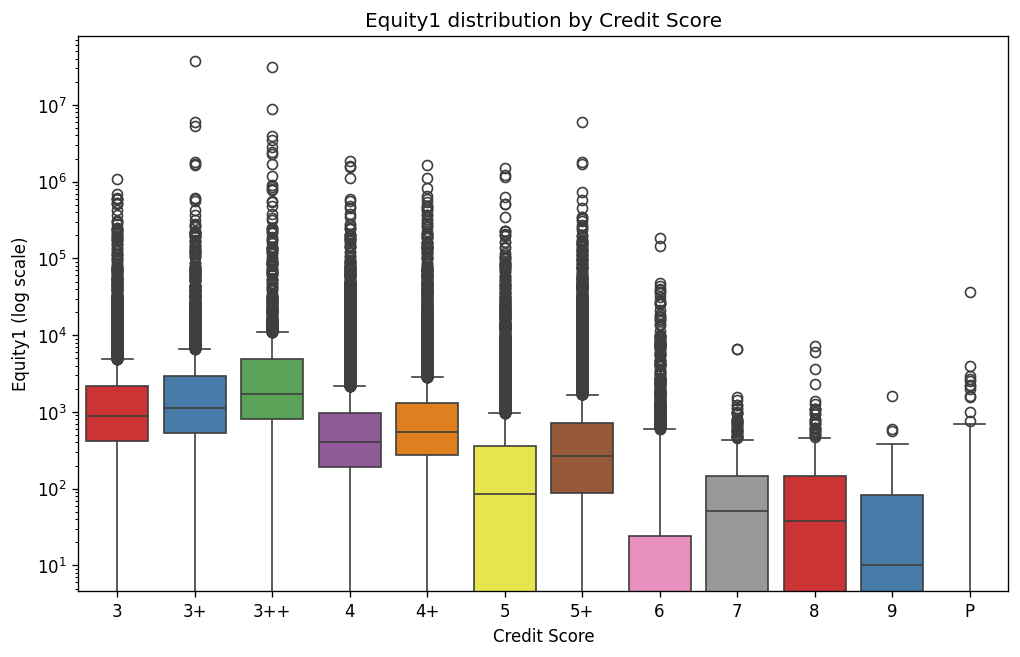

In [56]:
# equity1 vs credit_score
plt.figure(figsize=(10,6), dpi=120)
sns.boxplot(x='credit_score', y='equity1', data=df, palette='Set1')
plt.yscale('log')
plt.xlabel('Credit Score')
plt.ylabel('Equity1 (log scale)')
plt.title('Equity1 distribution by Credit Score')
plt.show()

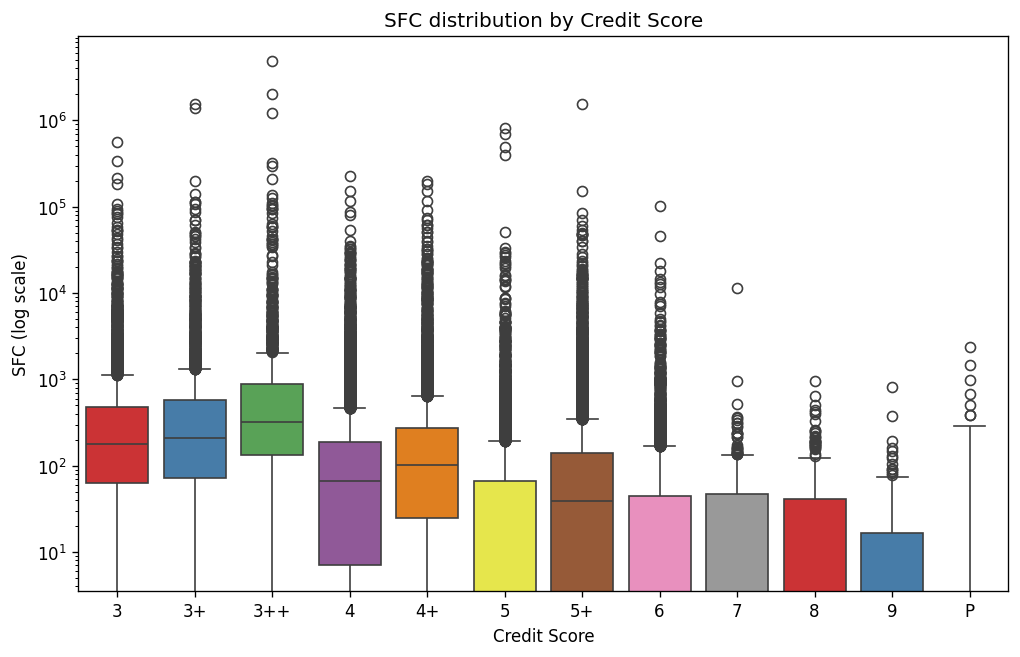

In [57]:
# sfc vs credit_score
plt.figure(figsize=(10,6), dpi=120)
sns.boxplot(x='credit_score', y='sfc', data=df, palette='Set1')
plt.yscale('log')
plt.xlabel('Credit Score')
plt.ylabel('SFC (log scale)')
plt.title('SFC distribution by Credit Score')
plt.show()

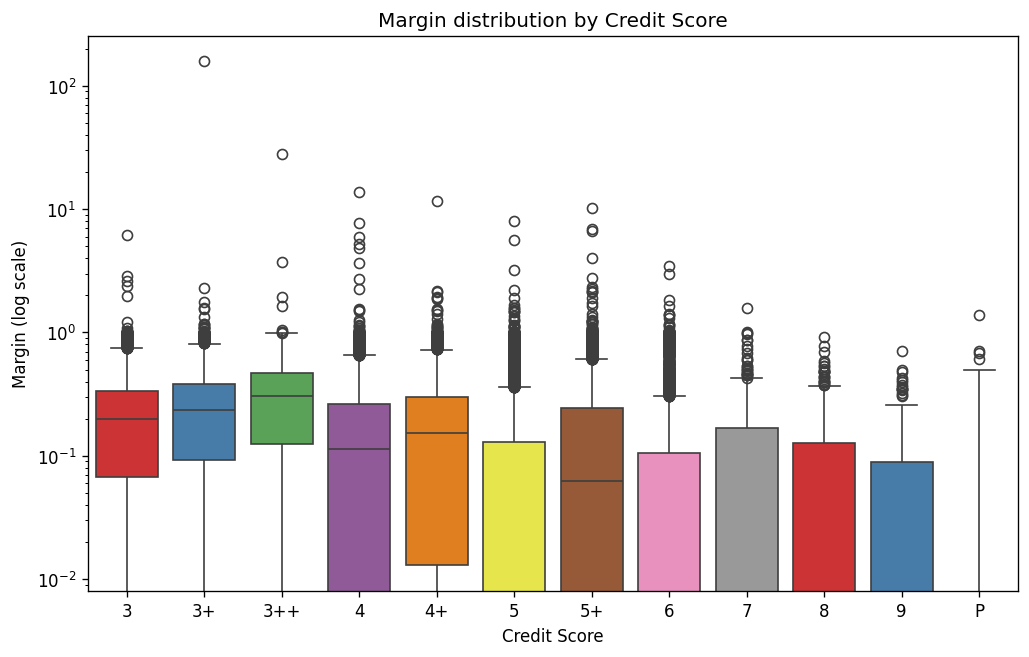

In [58]:
# margin vs credit_score
plt.figure(figsize=(10,6), dpi=120)
sns.boxplot(x='credit_score', y='margin', data=df, palette='Set1')
plt.yscale('log')
plt.xlabel('Credit Score')
plt.ylabel('Margin (log scale)')
plt.title('Margin distribution by Credit Score')
plt.show()

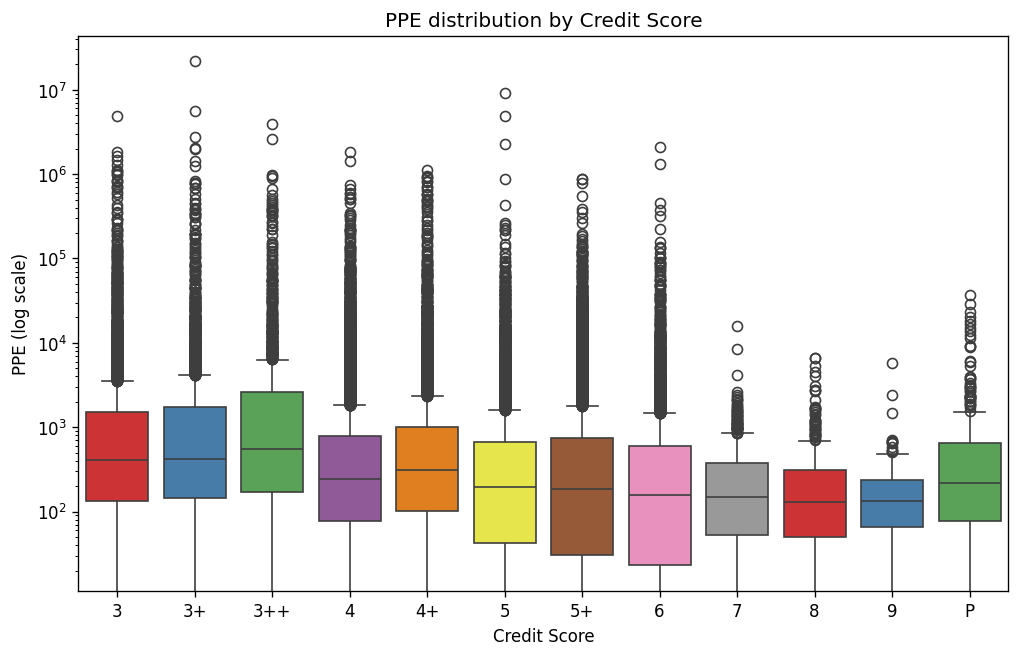

In [59]:
# ppe vs credit_score
plt.figure(figsize=(10,6), dpi=120)
sns.boxplot(x='credit_score', y='ppe', data=df, palette='Set1')
plt.yscale('log')
plt.xlabel('Credit Score')
plt.ylabel('PPE (log scale)')
plt.title('PPE distribution by Credit Score')
plt.show()

A general trend all over the different variables we used is a large number of outliers, which we aim to further investigate.

#### Outliers Investigation

In [60]:
df_numeric = df.select_dtypes(include=[np.number]).copy()
df_numeric.drop(columns=['id', 'year', 'year_creation'], inplace=True)
z_scores_df = df_numeric.apply(lambda col: (col - col.mean()) / col.std(ddof=0))

outlier_threshold = 3
outliers_mask = z_scores_df.abs() > outlier_threshold
outlier_counts = outliers_mask.sum().sort_values(ascending=False)

print("Outlier counts per column (|z| >", outlier_threshold, "):")
print(outlier_counts[outlier_counts > 0])

rows_with_outliers = outliers_mask.any(axis=1)
print(f"Rows with >=1 outlier: {rows_with_outliers.sum()}")

z_scores_df.head()

Outlier counts per column (|z| > 3 ):
tot_debt1          132
tot_debt           130
tot_debt2          123
bank_debt          121
turnover           118
sales              118
nbemp              118
financial_debt     116
bank_debt_lt       116
wcr                107
margin             105
investment         103
ppe                101
ppent              100
total_asset         82
stable_debt         74
total_actif         72
net_total_asset     72
capital             69
sfc                 50
equity1             35
other_debt          17
equity2              9
dtype: int64
Rows with >=1 outlier: 510


,turnover,total_actif,total_asset,net_total_asset,margin,wcr,sfc,bank_debt,bank_debt_lt,other_debt,...,stable_debt,financial_debt,tot_debt,investment,ppe,intangible,ppent,sales,capital,nbemp
0,-0.055342,-0.036571,-0.039896,-0.036562,0.162785,-0.023031,-0.020633,-0.040999,-0.036588,-0.011776,...,-0.028144,-0.043310,-0.058447,-0.039860,-0.038114,NaN,-0.038868,-0.055342,-0.030587,-0.073724
1,-0.068740,-0.041635,-0.043945,-0.041626,-0.005498,-0.019591,-0.027741,-0.053341,-0.049340,-0.011776,...,-0.033497,-0.039956,-0.058065,-0.040407,-0.035728,NaN,-0.037223,-0.068740,-0.033691,-0.084453
2,-0.054533,-0.037277,-0.040698,-0.037267,-0.005498,-0.019591,-0.027741,-0.046710,-0.042488,-0.011776,...,-0.030621,-0.045013,-0.059664,-0.040407,-0.039270,NaN,-0.040154,-0.054533,-0.031205,-0.084453
3,-0.060744,-0.036590,-0.038778,-0.036581,-0.005498,-0.019591,-0.027741,-0.020627,-0.015538,-0.011776,...,-0.019309,-0.031531,-0.050105,-0.039392,-0.026883,NaN,-0.029428,-0.060744,-0.029352,-0.076406
4,-0.058722,-0.035226,-0.037604,-0.035217,0.065977,-0.013114,-0.019735,-0.051241,-0.047170,-0.011776,...,-0.032586,-0.043520,-0.055293,-0.038376,-0.038967,NaN,-0.039896,-0.058722,-0.029136,-0.062994


Only 510 rows with outliers. It is sensible to keep them, as they may contain important information about extreemely high-risk or low risk companies.

We could also look at values 0 that don't make sense.

#### Feature Engineering

In [61]:
# create age feature
df['age'] = df['year'] - df['year_creation']

In [62]:
# create sales to total_asset ratio feature
ta = df['total_asset']
sales = df['sales']

valid = ta.notna() & (ta != 0)
df.loc[valid, 'sales_to_total_asset'] = sales[valid] / ta[valid]

max_ratio = df.loc[valid, 'sales_to_total_asset'].max()

df['sales_to_total_asset'] = df['sales_to_total_asset'].fillna(max_ratio)

In [63]:
# create debt to equity ratio feature
eq = df['equity1']
debt = df['tot_debt']

valid = eq.notna() & (eq != 0)
df.loc[valid, 'debt_to_equity'] = debt[valid] / eq[valid]

max_ratio = df.loc[valid, 'debt_to_equity'].max()

df['debt_to_equity'] = df['debt_to_equity'].fillna(max_ratio)

In [64]:
# create capital to total_asset ratio feature
ta = df['total_asset']
capital = df['capital']

valid = ta.notna() & (ta != 0)
df.loc[valid, 'capital_to_total_asset'] = capital[valid] / ta[valid]

max_ratio = df.loc[valid, 'capital_to_total_asset'].max()

df['capital_to_total_asset'] = df['capital_to_total_asset'].fillna(max_ratio)

In [65]:
df.dropna(inplace=True)

## Task 2 - Feature Selection & Feature Importance

### Train Test Split

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    ## we should decide what to do with industry variable
    df.drop(columns=['credit_score', 'id', 'year', 'year_creation', 'intangible', 'industry','total_actif', 'turnover']),
    df['credit_score'],
    test_size=0.2,
    random_state=42,
    stratify=df['credit_score']
)

### Mutual Information Classification

In [67]:
mutual_info = mutual_info_classif(X_train, y_train)

mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info.sort_values(ascending=False)

debt_to_equity            0.259320
equity1                   0.244364
sfc                       0.107916
margin                    0.082548
sales                     0.068324
net_total_asset           0.058002
total_asset               0.044776
sales_to_total_asset      0.042785
wcr                       0.040936
capital_to_total_asset    0.040174
investment                0.038231
age                       0.034470
nbemp                     0.032589
ppent                     0.032534
ppe                       0.031787
financial_debt            0.023296
capital                   0.021113
stable_debt               0.017431
bank_debt                 0.016960
tot_debt                  0.015230
tot_debt1                 0.013812
tot_debt2                 0.008341
bank_debt_lt              0.003467
other_debt                0.002628
equity2                   0.000250
dtype: float64

In [68]:
mutual_info.sort_values(ascending=False)[:10]

debt_to_equity            0.259320
equity1                   0.244364
sfc                       0.107916
margin                    0.082548
sales                     0.068324
net_total_asset           0.058002
total_asset               0.044776
sales_to_total_asset      0.042785
wcr                       0.040936
capital_to_total_asset    0.040174
dtype: float64

### PCA

In [69]:
X = X_train.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

loadings = pca.components_                     
explained = pca.explained_variance_ratio_    

weighted_loadings = np.abs(loadings) * explained[:, np.newaxis]
feature_importance = weighted_loadings.sum(axis=0)

importance_series = pd.Series(feature_importance, index=X.columns).sort_values(ascending=False)

print("Top 10 features by PCA importance:")
print(importance_series.head(10))

print("\nExplained variance:")
print(pd.Series(pca.explained_variance_ratio_[:10], index=[f"PC{i}" for i in range(1, min(10, pca.n_components_)+1)]))

Top 10 features by PCA importance:
bank_debt       0.171236
bank_debt_lt    0.170810
stable_debt     0.170014
nbemp           0.169677
other_debt      0.167586
sales           0.167005
equity2         0.166741
tot_debt2       0.166002
capital         0.165034
ppe             0.164820
dtype: float64

Explained variance:
PC1     0.366073
PC2     0.118305
PC3     0.103412
PC4     0.068957
PC5     0.046050
PC6     0.043029
PC7     0.041314
PC8     0.039954
PC9     0.038490
PC10    0.034463
dtype: float64


### LASSO Regression

In [70]:
lasso_clf = LogisticRegressionCV(
    Cs=10,
    penalty='l1',
    solver='saga',
    multi_class='multinomial',
    cv=5,
    scoring='accuracy',
    max_iter=2000,
    n_jobs=-1,
    random_state=42,
).fit(X_scaled, y_train)

# X_scaled is a numpy array; use the original dataframe's columns for feature names
coefs = pd.DataFrame(lasso_clf.coef_, index=lasso_clf.classes_, columns=X.columns)

abs_sum = coefs.abs().sum(axis=0)
dropped_features = list(abs_sum[abs_sum == 0].index)
retained_features = list(abs_sum[abs_sum > 0].sort_values(ascending=False).index)

print(f"Number of features: {X_train.shape[1]}")
print(f"Features dropped (all-zero coefficients): {len(dropped_features)}")
print(dropped_features)
print("\nTop retained features by sum(|coef|):")
print(abs_sum.sort_values(ascending=False).head(15))

Number of features: 25
Features dropped (all-zero coefficients): 0
[]

Top retained features by sum(|coef|):
margin                    14.385369
sales_to_total_asset       6.635927
equity1                    5.890763
age                        3.800176
sfc                        3.649939
net_total_asset            2.927056
sales                      2.915047
nbemp                      2.705600
capital_to_total_asset     2.099999
financial_debt             2.096446
bank_debt_lt               1.825187
tot_debt2                  1.689692
other_debt                 1.588217
tot_debt                   1.520720
tot_debt1                  1.496443
dtype: float64


### RFE

In [71]:
est = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

k = 10
rfe = RFE(estimator=est, n_features_to_select=k, step=1)
rfe.fit(X_scaled, y_train)

selected_features_rfe = X.columns[rfe.support_].tolist()
ranking = pd.Series(rfe.ranking_, index=X.columns).sort_values()
print(f"Top-{k} RFE features:")
print(selected_features_rfe)
print("Feature ranking (1 = selected):")
print(ranking.head(20))

Top-10 RFE features:
['total_asset', 'sfc', 'tot_debt2', 'equity1', 'financial_debt', 'ppent', 'sales', 'sales_to_total_asset', 'debt_to_equity', 'capital_to_total_asset']
Feature ranking (1 = selected):
total_asset                1
sales_to_total_asset       1
sales                      1
ppent                      1
financial_debt             1
debt_to_equity             1
equity1                    1
tot_debt2                  1
capital_to_total_asset     1
sfc                        1
margin                     2
tot_debt                   3
age                        4
capital                    5
wcr                        6
net_total_asset            7
ppe                        8
stable_debt                9
tot_debt1                 10
nbemp                     11
dtype: int64


### Feature Importance with Random Forests

Top features (Gini importances):
debt_to_equity            0.078367
equity1                   0.071844
sfc                       0.053500
capital_to_total_asset    0.050665
sales                     0.049409
sales_to_total_asset      0.047458
margin                    0.045937
age                       0.043602
wcr                       0.043235
tot_debt2                 0.042265
financial_debt            0.041421
capital                   0.040830
total_asset               0.040272
net_total_asset           0.039836
ppent                     0.038769
ppe                       0.038290
tot_debt                  0.036829
tot_debt1                 0.036731
nbemp                     0.035076
investment                0.034764
dtype: float64


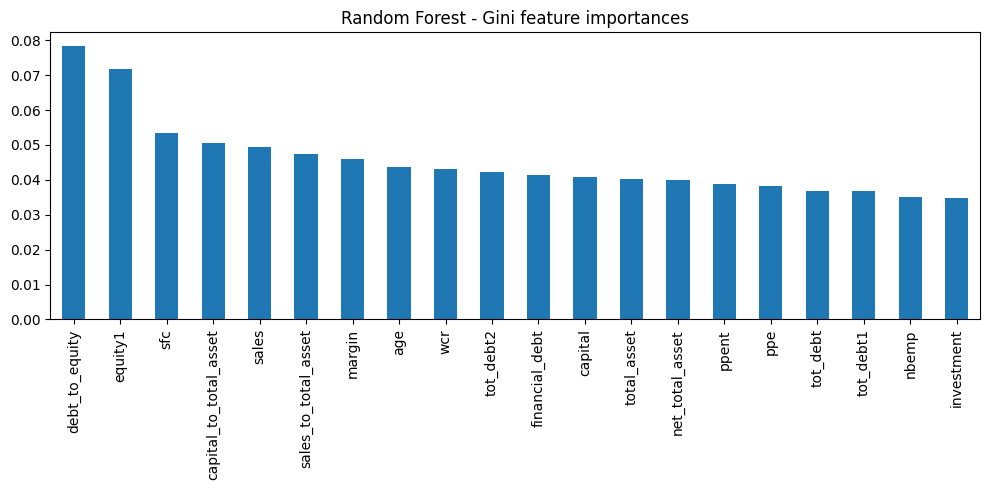


Top features (permutation importances):
equity1                   0.049002
debt_to_equity            0.030567
sfc                       0.014443
capital_to_total_asset    0.012733
margin                    0.007357
sales                     0.003942
age                       0.003485
sales_to_total_asset      0.002518
stable_debt               0.002126
wcr                       0.001775
investment                0.001249
financial_debt            0.001133
bank_debt_lt              0.000817
bank_debt                 0.000547
ppe                       0.000431
equity2                   0.000381
other_debt                0.000070
nbemp                    -0.000065
tot_debt2                -0.000206
net_total_asset          -0.000421
dtype: float64


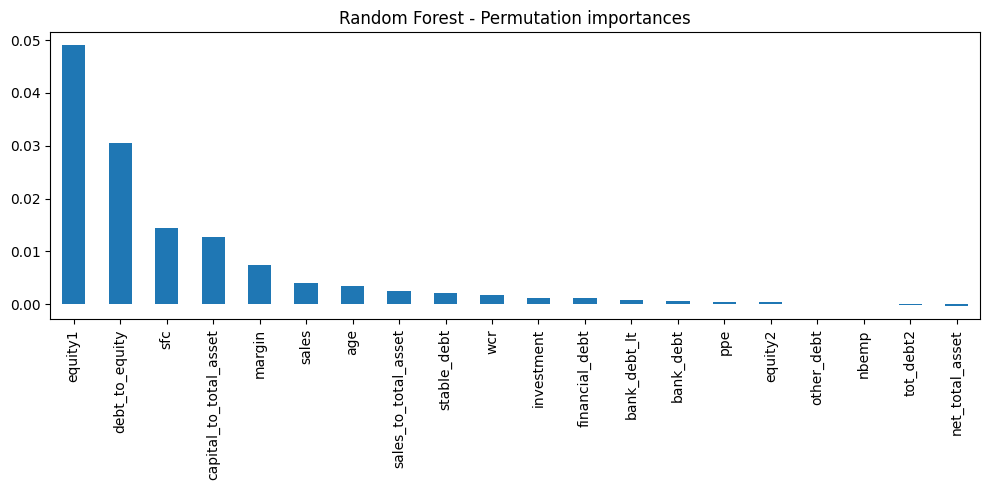

In [72]:
rf_feat = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_feat.fit(X_scaled, y_train)

importances = pd.Series(rf_feat.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top features (Gini importances):")
print(importances.head(20))

plt.figure(figsize=(10,5))
importances.head(20).plot(kind='bar')
plt.title('Random Forest - Gini feature importances')
plt.tight_layout()
plt.show()

X_test_scaled = scaler.transform(X_test)   
perm = permutation_importance(rf_feat, X_test_scaled, y_test, n_repeats=20, random_state=42, n_jobs=-1)
perm_importances = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
print("\nTop features (permutation importances):")
print(perm_importances.head(20))

plt.figure(figsize=(10,5))
perm_importances.head(20).plot(kind='bar')
plt.title('Random Forest - Permutation importances')
plt.tight_layout()
plt.show()

### Feature Importance with XGBoost

Top features (Gini importances):
equity1                   0.163914
debt_to_equity            0.058427
sfc                       0.047993
stable_debt               0.043144
capital_to_total_asset    0.040079
sales                     0.039781
margin                    0.038808
sales_to_total_asset      0.035851
bank_debt                 0.035550
bank_debt_lt              0.034313
ppe                       0.033674
ppent                     0.033545
financial_debt            0.033244
capital                   0.032948
tot_debt1                 0.032251
investment                0.032245
wcr                       0.031829
tot_debt2                 0.031651
nbemp                     0.031539
net_total_asset           0.031092
dtype: float32


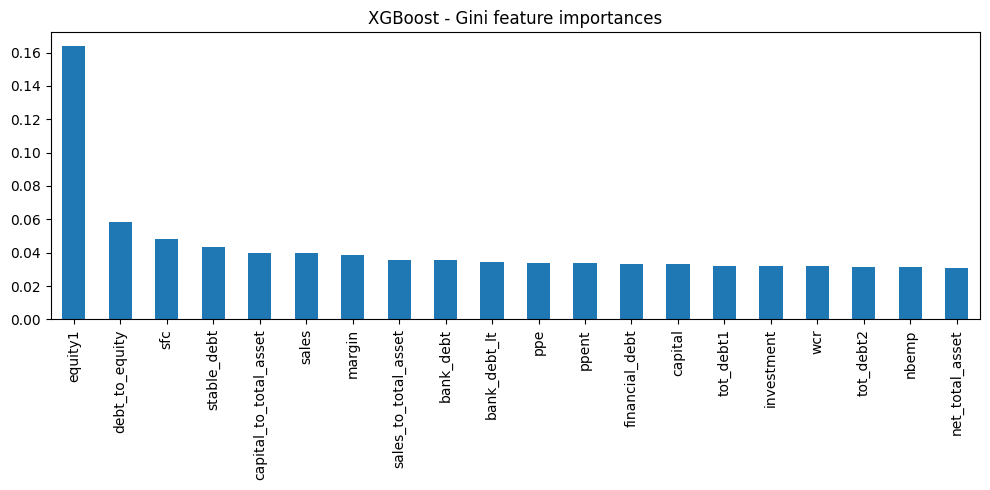


Top features (permutation importances):
equity1                   0.078566
debt_to_equity            0.033019
capital_to_total_asset    0.018395
sfc                       0.017217
bank_debt_lt              0.014363
sales                     0.013666
financial_debt            0.010211
stable_debt               0.010186
bank_debt                 0.008751
net_total_asset           0.008390
ppe                       0.008164
margin                    0.007031
tot_debt2                 0.007011
wcr                       0.006861
sales_to_total_asset      0.006846
investment                0.006695
capital                   0.006148
nbemp                     0.005527
tot_debt1                 0.005456
total_asset               0.004925
dtype: float64


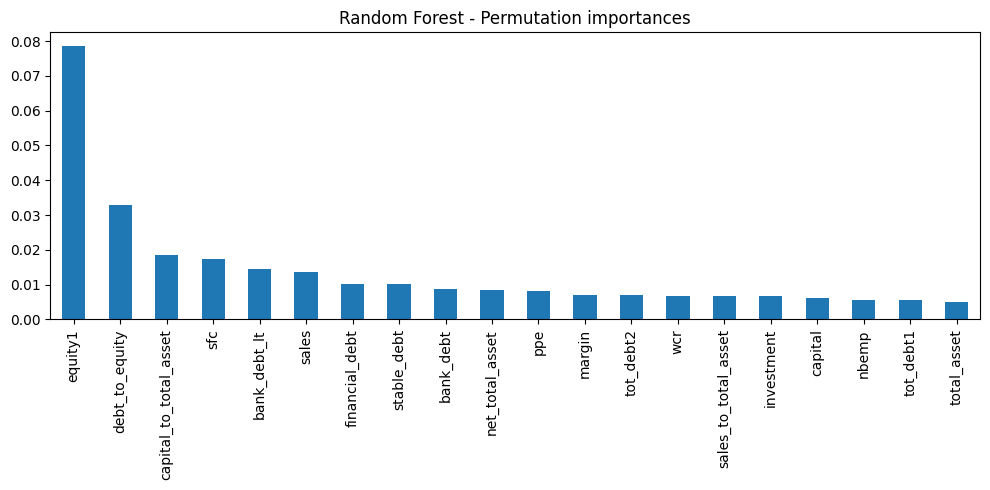

In [73]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_feat = xgb.XGBClassifier(n_estimators=200, random_state=42, n_jobs=-1)
xgb_feat.fit(X_scaled, y_train_enc)


importances = pd.Series(xgb_feat.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top features (Gini importances):")
print(importances.head(20))

plt.figure(figsize=(10,5))
importances.head(20).plot(kind='bar')
plt.title('XGBoost - Gini feature importances')
plt.tight_layout()
plt.show()


X_test_scaled = scaler.transform(X_test)   
perm = permutation_importance(xgb_feat, X_test_scaled, y_test_enc, n_repeats=20, random_state=42, n_jobs=-1)
perm_importances = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
print("\nTop features (permutation importances):")
print(perm_importances.head(20))

plt.figure(figsize=(10,5))
perm_importances.head(20).plot(kind='bar')
plt.title('Random Forest - Permutation importances')
plt.tight_layout()
plt.show()

### Final Feature Selection

Given the results from the different feature selection methods, we will select the following features for our final model:
- equity1
- debt_to_equity
- sfc
- margin
- capital_to_total_assets
- bank_debt
- sales
- net_total_assets
- tot_debt
- sales_to_total_assets
- financial_debt
- age
- wcr
- nbemp
- capital

## Task 3 - Prediction Models

### Multinomial Logistic Regression

In [74]:
# Select features
selected_cols = [
    'equity1', 'debt_to_equity', 'sfc', 'margin',
    'capital_to_total_asset', 'bank_debt', 'sales',
    'net_total_asset', 'tot_debt', 'sales_to_total_asset',
    'financial_debt', 'age', 'wcr', 'nbemp', 'capital'
]
X_train_selected = X_train[selected_cols].copy()
X_test_selected = X_test[selected_cols].copy()

In [75]:
# Standardize features
scaler_sel = StandardScaler()
X_train_selected = scaler_sel.fit_transform(X_train_selected)
X_test_selected = scaler_sel.transform(X_test_selected)

# Multinomial Logistic Regression
log_reg = LogisticRegression(
    multi_class='multinomial',   # allows multi-class classification
    solver='lbfgs',              # efficient for multinomial problems
    max_iter=1000,               # increase iterations for convergence
    random_state=42
)

# Fit model
log_reg.fit(X_train_selected, y_train_enc)

# Predict
y_pred = log_reg.predict(X_test_selected)

# Convert encoded labels back to original labels
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test_enc)

# Print classification report
print(classification_report(y_test_labels, y_pred_labels))


              precision    recall  f1-score   support

           3       0.16      0.02      0.03       885
          3+       0.00      0.00      0.00       563
         3++       0.16      0.01      0.03       281
           4       0.25      0.55      0.34      2041
          4+       0.17      0.01      0.01      1356
           5       0.36      0.01      0.02      1292
          5+       0.30      0.65      0.41      2401
           6       0.28      0.01      0.02       846
           7       0.00      0.00      0.00       103
           8       0.00      0.00      0.00        96
           9       0.00      0.00      0.00        29
           P       0.00      0.00      0.00        77

    accuracy                           0.27      9970
   macro avg       0.14      0.11      0.07      9970
weighted avg       0.24      0.27      0.18      9970



### RF

Random Forest Classification Report:
              precision    recall  f1-score   support

           3       0.20      0.23      0.21       885
          3+       0.18      0.31      0.23       563
         3++       0.18      0.49      0.26       281
           4       0.37      0.32      0.35      2041
          4+       0.26      0.20      0.23      1356
           5       0.31      0.15      0.20      1292
          5+       0.52      0.32      0.40      2401
           6       0.43      0.55      0.48       846
           7       0.04      0.16      0.07       103
           8       0.04      0.20      0.06        96
           9       0.04      0.10      0.06        29
           P       0.12      0.49      0.19        77

    accuracy                           0.30      9970
   macro avg       0.22      0.29      0.23      9970
weighted avg       0.35      0.30      0.31      9970

equity1                   0.163914
debt_to_equity            0.058427
sfc                       

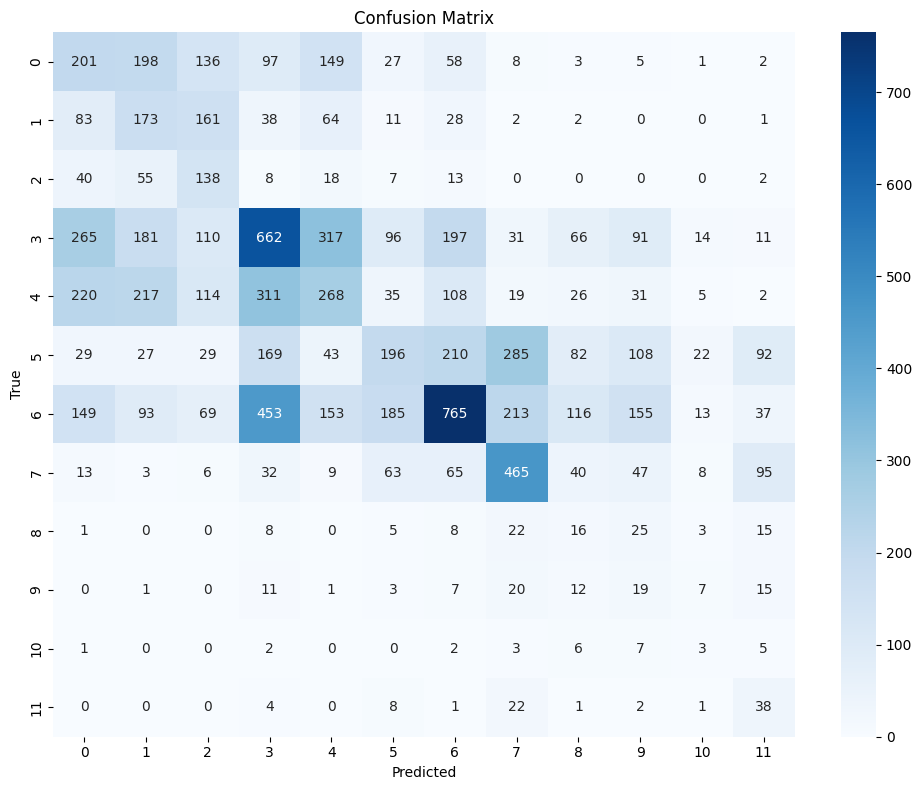

In [76]:
# Create and train Random Forest model with class weight balancing
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Fit the model
rf.fit(X_train_selected, y_train_enc)

# Make predictions
rf_pred = rf.predict(X_test_selected)

rf_pred_labels = le.inverse_transform(rf_pred)
y_test_labels = le.inverse_transform(y_test_enc)

# Print classification report
print("Random Forest Classification Report:")
print(classification_report(y_test_labels, rf_pred_labels))

print(importances.head(10))

# Confusion matrix
cm = confusion_matrix(y_test_labels, rf_pred_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

Here we run a RandomForest (200 trees, max_depth=10, sqrt features, class_weight='balanced') and evaluate on the test set.
Test accuracy ≈ 30% (weighted F1 ≈ 0.31): mid-frequency classes (4–6) are moderate, while rare classes (7–9, P) show high recall but low precision, indicating imbalance/overlap.
Top features driving the model include net_total_asset (~0.054), capital_to_total_asset (~0.052), and tot_debt (~0.052).

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END bootstrap=True, class_weight=balanced_subsample, max_depth=17, max_features=None, min_samples_leaf=8, min_samples_split=8, n_estimators=221; total time= 1.3min
[CV] END bootstrap=True, class_weight=balanced_subsample, max_depth=17, max_features=None, min_samples_leaf=8, min_samples_split=8, n_estimators=221; total time= 1.3min
[CV] END bootstrap=True, class_weight=balanced_subsample, max_depth=17, max_features=None, min_samples_leaf=8, min_samples_split=8, n_estimators=221; total time= 1.3min
[CV] END bootstrap=True, class_weight=balanced_subsample, max_depth=17, max_features=None, min_samples_leaf=8, min_samples_split=8, n_estimators=221; total time= 1.3min
[CV] END bootstrap=True, class_weight=balanced_subsample, max_depth=17, max_features=None, min_samples_leaf=8, min_samples_split=8, n_estimators=221; total time= 1.3min
[CV] END bootstrap=False, class_weight=balanced, max_depth=4, max_features=log2, min_samples

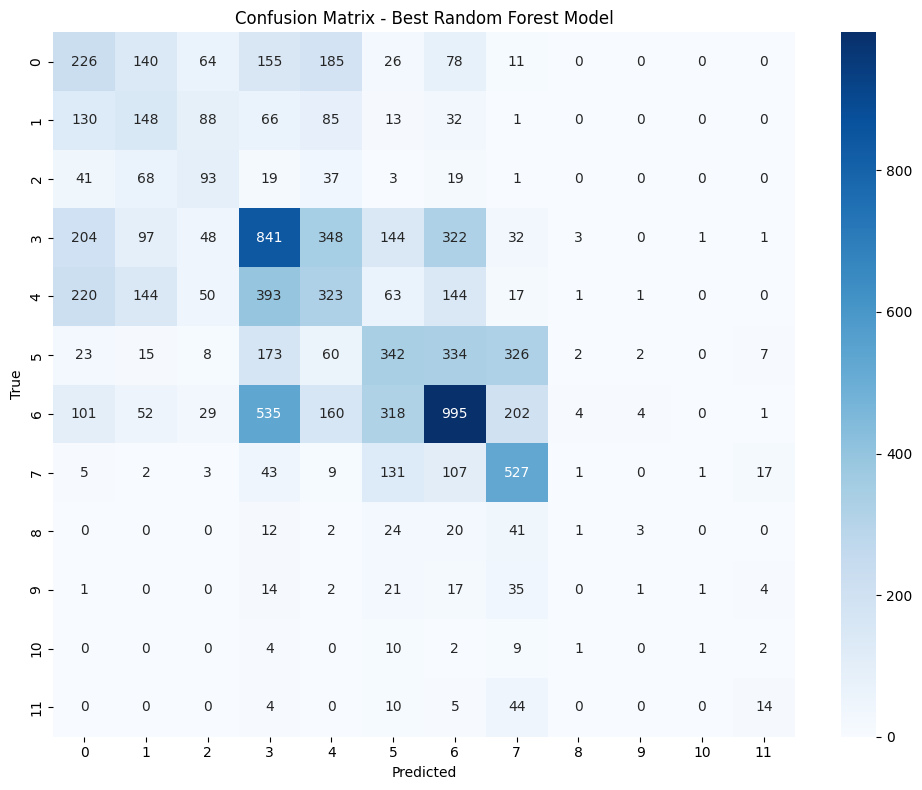

In [77]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import numpy as np

# Define the parameter space
param_distributions = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample'],
    'bootstrap': [True, False]
}

# Create Random Forest classifier
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Create RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=100,  
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Fit RandomizedSearchCV
rf_random.fit(X_train_selected, y_train_enc)


# Print best parameters and score
print("\nBest parameters found:")
print(rf_random.best_params_)
print("\nBest cross-validation score:")
print(rf_random.best_score_)

# Make predictions with best model
best_rf_pred = rf_random.best_estimator_.predict(X_test_selected)
best_rf_pred_labels = le.inverse_transform(best_rf_pred)
y_test_labels = le.inverse_transform(y_test_enc)

# Print classification report
print("\nClassification Report for Best Model:")
print(classification_report(y_test_labels, best_rf_pred_labels))

# Plot confusion matrix
cm = confusion_matrix(y_test_labels, best_rf_pred_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Best Random Forest Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

This cell runs a RandomizedSearchCV over a Random Forest, sampling 100 hyperparameter combinations with 5-fold CV, optimizing weighted F1 on all cores.
The best config was with a CV F1≈0.343.
On the held-out test set, accuracy is ~35% and weighted F1 is ~0.34; performance is stronger on frequent mid-range classes (4–5+) and weak on rare labels (7–9, P), again indicating class imbalance and overlapping features.

In [78]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestClassifier

# CV: fewer folds for search
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Fast(er) search space (remove max_features=None; add max_samples)
param_distributions_stage1 = {
    "n_estimators": randint(120, 320),             
    "max_depth": randint(4, 20),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2"],              # drop None (slow)
    "class_weight": ["balanced", "balanced_subsample"],
    "bootstrap": [True, False],
    "max_samples": uniform(0.6, 0.35)              # 0.60–0.95 (ignored if bootstrap=False)
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)  

rf_random_stage1 = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions_stage1,
    n_iter=80,                     # fewer trials; broader space
    cv=cv,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=1,                      # avoid nested parallelism
    verbose=1
)

rf_random_stage1.fit(X_train_selected, y_train_enc)
best1 = rf_random_stage1.best_params_
best1, rf_random_stage1.best_score_


Fitting 3 folds for each of 80 candidates, totalling 240 fits


({'bootstrap': True,
  'class_weight': 'balanced',
  'max_depth': 18,
  'max_features': 'log2',
  'max_samples': 0.7287240964517386,
  'min_samples_leaf': 4,
  'min_samples_split': 3,
  'n_estimators': 317},
 0.3412178350914852)

In [79]:
# tighten ranges around stage1 bests
param_distributions_stage2 = {
    "n_estimators": randint(200, 450),
    "max_depth": randint(max(3, best1["max_depth"]-4), best1["max_depth"]+4),
    "min_samples_split": randint(max(2, best1["min_samples_split"]-5), best1["min_samples_split"]+6),
    "min_samples_leaf": randint(1, min(10, best1["min_samples_leaf"]+3)),
    "max_features": [best1["max_features"]],
    "class_weight": [best1["class_weight"]],
    "bootstrap": [best1["bootstrap"]],
    "max_samples": uniform(
        max(0.6, (best1.get("max_samples", 0.8) - 0.15)),
        min(0.35, (best1.get("max_samples", 0.8) + 0.15) - max(0.6, (best1.get("max_samples", 0.8) - 0.15)))
    )
}

rf_random_stage2 = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions_stage2,
    n_iter=24,
    cv=cv,
    scoring="f1_weighted",
    random_state=43,
    n_jobs=1,
    verbose=1
)

rf_random_stage2.fit(X_train_selected, y_train_enc)
best2 = rf_random_stage2.best_params_
best2, rf_random_stage2.best_score_


Fitting 3 folds for each of 24 candidates, totalling 72 fits


({'bootstrap': True,
  'class_weight': 'balanced',
  'max_depth': 20,
  'max_features': 'log2',
  'max_samples': 0.6125573177626445,
  'min_samples_leaf': 1,
  'min_samples_split': 5,
  'n_estimators': 327},
 0.34438341777413545)

In [80]:
final_rf = RandomForestClassifier(
    **{**best2, "n_estimators": 800, "max_samples": None},
    random_state=42,
    n_jobs=-1
)
final_rf.fit(X_train_selected, y_train_enc)

from sklearn.metrics import classification_report, confusion_matrix
best_rf_pred = final_rf.predict(X_test_selected)
best_rf_pred_labels = le.inverse_transform(best_rf_pred)
y_test_labels = le.inverse_transform(y_test_enc)

print(classification_report(y_test_labels, best_rf_pred_labels))


              precision    recall  f1-score   support

           3       0.24      0.24      0.24       885
          3+       0.24      0.21      0.23       563
         3++       0.29      0.29      0.29       281
           4       0.37      0.44      0.40      2041
          4+       0.27      0.24      0.26      1356
           5       0.31      0.23      0.26      1292
          5+       0.45      0.46      0.46      2401
           6       0.43      0.59      0.50       846
           7       0.25      0.01      0.02       103
           8       0.00      0.00      0.00        96
           9       0.33      0.03      0.06        29
           P       0.33      0.10      0.16        77

    accuracy                           0.36      9970
   macro avg       0.29      0.24      0.24      9970
weighted avg       0.35      0.36      0.35      9970



Runs a two-stage RandomizedSearchCV for Random Forest with 3-fold CV: a fast, broad Stage-1 (80 trials) followed by a focused Stage-2 (24 trials), using max_samples subsampling during search to speed things up.
Best configs were close (F1_cv≈0.340 → 0.345), and the final model (refit with more trees) reaches test accuracy ≈ 36% and weighted F1 ≈ 0.35 (macro F1 ≈ 0.24).
Performance improves slightly over the single-stage search; mid/frequent classes (4–6) are reasonable (e.g., class 6 recall 0.61), but rare labels (7–9, P) remain weak (e.g., class 8 recall 0.00).

In [81]:
import optuna
from optuna.pruners import PercentilePruner
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 120, 320),
        "max_depth": trial.suggest_int("max_depth", 4, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample"]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "max_samples": None,
        "random_state": 42,
        "n_jobs": -1,
    }
    if params["bootstrap"]:
        params["max_samples"] = trial.suggest_float("max_samples", 0.60, 0.95)

    rf = RandomForestClassifier(**params)


    scores = cross_val_score(
        rf,
        X_train_selected, y_train_enc,
        cv=cv,
        scoring="f1_weighted",
        n_jobs=1,
        error_score="raise"
    )
    return scores.mean()


study = optuna.create_study(
    direction="maximize",
    pruner=PercentilePruner(percentile=25, n_startup_trials=15, n_warmup_steps=0)
)
study.optimize(objective, n_trials=80, show_progress_bar=True)

print("Best trial:", study.best_trial.number)
print("Best CV F1:", study.best_value)
print("Best params:", study.best_params)


# For the final model, we turn off subsampling for max accuracy and bump trees for stability.
best = study.best_params.copy()
bootstrap = best["bootstrap"]
best["n_estimators"] = 800
best["random_state"] = 42
best["n_jobs"] = -1
best["max_samples"] = None

final_rf = RandomForestClassifier(**best)
final_rf.fit(X_train_selected, y_train_enc)

# Evaluate on test set
best_rf_pred = final_rf.predict(X_test_selected)
best_rf_pred_labels = le.inverse_transform(best_rf_pred)
y_test_labels = le.inverse_transform(y_test_enc)

print("\nClassification Report (Final RF):")
print(classification_report(y_test_labels, best_rf_pred_labels))

[I 2025-10-31 14:35:21,106] A new study created in memory with name: no-name-71087d30-180b-4ecf-a042-52cf9f5d7cda


  0%|          | 0/80 [00:00<?, ?it/s]

[I 2025-10-31 14:42:24,044] Trial 0 finished with value: 0.25246007614719357 and parameters: {'n_estimators': 211, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'class_weight': 'balanced', 'bootstrap': False}. Best is trial 0 with value: 0.25246007614719357.
[I 2025-10-31 14:42:47,116] Trial 1 finished with value: 0.3351653042407106 and parameters: {'n_estimators': 251, 'max_depth': 17, 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': 'balanced_subsample', 'bootstrap': False}. Best is trial 1 with value: 0.3351653042407106.
[I 2025-10-31 14:43:06,067] Trial 2 finished with value: 0.2775919014373442 and parameters: {'n_estimators': 307, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'log2', 'class_weight': 'balanced_subsample', 'bootstrap': False}. Best is trial 1 with value: 0.3351653042407106.
[I 2025-10-31 14:43:22,244] Trial 3 finished with value: 0.33988817482648076 and

After the one-shot RandomizedSearch and the two-stage narrowing, we moved to Optuna with a PercentilePruner to adaptively focus trials on promising regions and stop weak ones early—giving slightly better CV scores with similar or less compute. We ran 80 trials with 5-fold stratified CV, searching the same core RF knobs (including conditional max_samples when bootstrap=True). 

The best study trial reached CV F1 ≈ 0.346, with params close to prior wins (max_depth≈18–20, log2 features, class weighting, moderate subsampling). We then refit a final model with more trees (800) and no subsampling for stability: on test it yields accuracy ≈ 36%, weighted F1 ≈ 0.35, macro F1 ≈ 0.25. As before, mid/high-support classes (4–6) are OK (e.g., class 6 recall 0.60), while rare labels (7–9, P) remain weak—suggesting gains now depend more on data/labels or re-framing than further RF tuning.

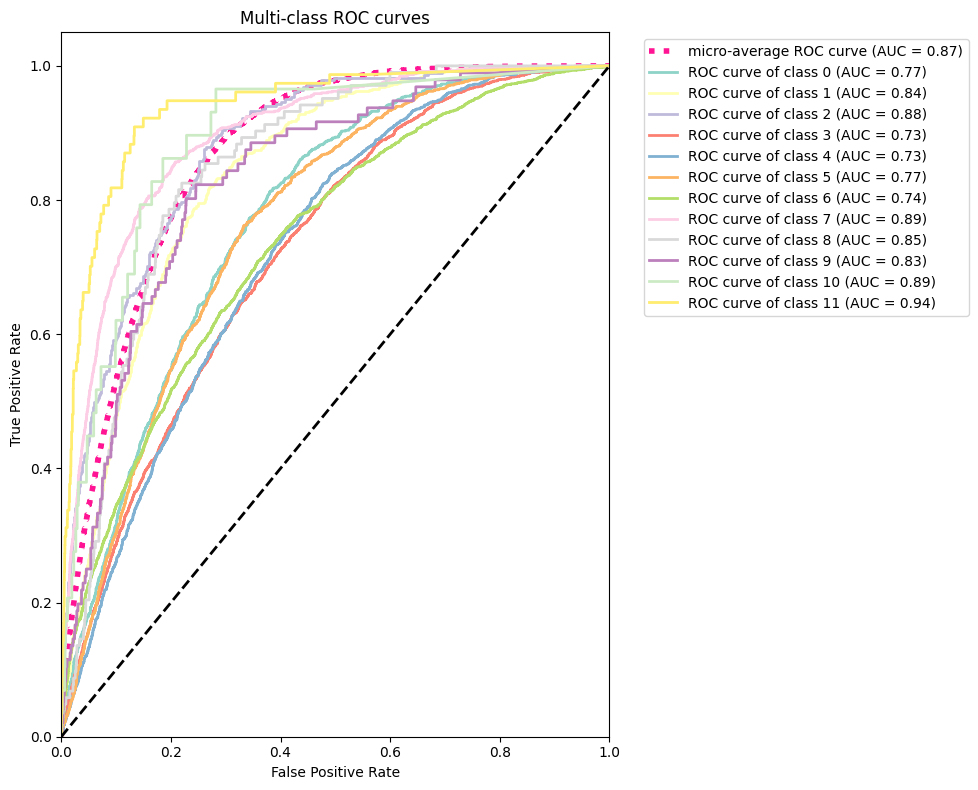


Micro-average AUC: 0.870

AUC scores per class:
Class 0: 0.775
Class 1: 0.840
Class 2: 0.880
Class 3: 0.725
Class 4: 0.727
Class 5: 0.766
Class 6: 0.738
Class 7: 0.895
Class 8: 0.851
Class 9: 0.832
Class 10: 0.891
Class 11: 0.937


In [82]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

import matplotlib.pyplot as plt

# Get predicted probabilities
y_pred_proba = final_rf.predict_proba(X_test_selected)

# Binarize the test labels
classes = final_rf.classes_
y_test_bin = label_binarize(y_test_enc, classes=range(len(classes)))

# Calculate ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calculate micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure(figsize=(10, 8))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average ROC curve (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=4)

# Plot ROC curves for each class
colors = plt.cm.Set3(np.linspace(0, 1, len(classes)))
for i, color in zip(range(len(classes)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC curves')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print average AUC
print(f"\nMicro-average AUC: {roc_auc['micro']:.3f}")
print("\nAUC scores per class:")
for i in range(len(classes)):
    print(f"Class {classes[i]}: {roc_auc[i]:.3f}")

This cell plots multi-class ROC curves to evaluate the discriminative ability of the final Random Forest model across all labels.
Predicted probabilities are used to compute per-class AUC (Area Under the Curve) and a micro-averaged AUC, which aggregates performance across all classes.

The micro-average AUC = 0.868, showing good overall ranking ability despite modest accuracy.
Class-level AUCs range from 0.72–0.93, with strongest separation for classes like 7, 10, 11 (AUC > 0.85) and weaker separation for mid-range, overlapping classes (3–6).
This indicates the model can generally rank class probabilities well even where decision boundaries overlap, and highlights which labels are easiest or hardest to distinguish.

In [ ]:
selected_cols = [
    'equity1', 'debt_to_equity', 'sfc', 'margin',
    'capital_to_total_asset', 'bank_debt', 'sales',
    'net_total_asset', 'tot_debt', 'sales_to_total_asset',
    'financial_debt', 'age', 'wcr', 'nbemp', 'capital'
]

# Ensure the engineered features exist in the test set (same logic used when creating them for df)
# 1) age
test['age'] = test['year'] - test['year_creation']

# 2) sales_to_total_asset
ta = test['total_asset']
sales = test['sales']
valid = ta.notna() & (ta != 0)
test.loc[valid, 'sales_to_total_asset'] = sales[valid] / ta[valid]

# 3) debt_to_equity
eq = test['equity1']
debt = test['tot_debt']
valid = eq.notna() & (eq != 0)
test.loc[valid, 'debt_to_equity'] = debt[valid] / eq[valid]

# 4) capital_to_total_asset
ta = test['total_asset']
capital = test['capital']
valid = ta.notna() & (ta != 0)
test.loc[valid, 'capital_to_total_asset'] = capital[valid] / ta[valid]

# Now build X_new from test
X_new = test[selected_cols].copy()

# Fill any remaining NaNs using the training medians (use X_train DataFrame from earlier)
# Note: X_train is the DataFrame used to train models (not the scaled array)
train_medians = X_train[selected_cols].median()
X_new = X_new.fillna(train_medians)

# Scale using the scaler used during training of the selected features
# scaler_sel was fitted previously; use it to transform X_new
X_new_scaled = scaler_sel.transform(X_new)

# Predict with the final Random Forest (expects scaled features)
y_new_pred_enc = final_rf.predict(X_new_scaled)
y_new_pred_labels = le.inverse_transform(y_new_pred_enc)

# For multiclass, get the probability of the predicted class for each sample
if hasattr(final_rf, "predict_proba"):
    proba = final_rf.predict_proba(X_new_scaled)
    y_new_proba = proba[np.arange(len(y_new_pred_enc)), y_new_pred_enc]
else:
    y_new_proba = np.zeros(len(y_new_pred_labels))

results_df = test.copy()
results_df["predicted_label"] = y_new_pred_labels
results_df["predicted_proba"] = y_new_proba

# If the true labels exist in this test set, print a report (encode with the same LabelEncoder)
if "label_reduced" in test.columns:
    y_true_enc = le.transform(test["label_reduced"])
    print("\nClassification Report (new test set):")
    print(classification_report(y_true_enc, y_new_pred_enc, target_names=le.classes_))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true_enc, y_new_pred_enc))

output_path = "rf_predictions.txt"

results_df[["predicted_label", "predicted_proba"]].to_csv(
    output_path, sep="\t", index=False, float_format="%.4f"
)

print(f"\n✅ Predictions saved: {output_path}")


✅ Predictions saved: rf_predictions.txt


Given that the RF is giving us the best results we decided to use this model for our submission.

### XGBoost Classifier Base

First attempt with a base XGBoost classifier.

In [83]:
selected_cols = [
    'equity1', 'debt_to_equity', 'sfc', 'margin',
    'capital_to_total_asset', 'bank_debt', 'sales',
    'net_total_asset', 'tot_debt', 'sales_to_total_asset',
    'financial_debt', 'age', 'wcr', 'nbemp', 'capital'
]

X_train_selected = X_train[selected_cols].copy()
X_test_selected = X_test[selected_cols].copy()


# scaler_sel = StandardScaler()
# X_train_selected = scaler_sel.fit_transform(X_train_selected)
# X_test_selected = scaler_sel.transform(X_test_selected)

In [84]:
xgb_base = xgb.XGBClassifier(n_estimators=200, max_depth=1, eta = 0.3, subsample = 0.6, colsample_bytree = 0.75, random_state=42, n_jobs=-1)

xgb_base.fit(X_train_selected, y_train_enc)
xgb_base_pred = xgb_base.predict(X_test_selected)

xgb_base_pred_labels = le.inverse_transform(xgb_base_pred)
y_test_labels = le.inverse_transform(y_test_enc)
print(f'{classification_report(y_test_labels, xgb_base_pred_labels)}')

              precision    recall  f1-score   support

           3       0.27      0.15      0.19       885
          3+       0.30      0.14      0.19       563
         3++       0.28      0.20      0.23       281
           4       0.33      0.56      0.42      2041
          4+       0.27      0.15      0.19      1356
           5       0.31      0.14      0.19      1292
          5+       0.41      0.54      0.46      2401
           6       0.43      0.59      0.50       846
           7       0.00      0.00      0.00       103
           8       0.00      0.00      0.00        96
           9       0.00      0.00      0.00        29
           P       0.00      0.00      0.00        77

    accuracy                           0.36      9970
   macro avg       0.22      0.20      0.20      9970
weighted avg       0.33      0.36      0.32      9970



Results are unsatisfactory, so we will proceed with SMOTE to try and approach class imbalance.

In [89]:
# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_selected.astype(float), y_train_enc)

xgb_smote = xgb.XGBClassifier(n_estimators=200, max_depth=1, eta = 0.3, subsample = 0.6, colsample_bytree = 0.75, random_state=42, n_jobs=-1)
xgb_smote.fit(X_train_smote, y_train_smote)
xgb_smote_pred = xgb_smote.predict(X_test_selected)
xgb_smote_pred_labels = le.inverse_transform(xgb_smote_pred)
y_test_labels = le.inverse_transform(y_test_enc)
print(f'{classification_report(y_test_labels, xgb_smote_pred_labels)}')

              precision    recall  f1-score   support

           3       0.19      0.20      0.20       885
          3+       0.14      0.24      0.18       563
         3++       0.13      0.51      0.21       281
           4       0.35      0.25      0.29      2041
          4+       0.23      0.17      0.20      1356
           5       0.27      0.10      0.14      1292
          5+       0.50      0.28      0.36      2401
           6       0.43      0.48      0.45       846
           7       0.04      0.17      0.06       103
           8       0.04      0.23      0.07        96
           9       0.03      0.45      0.06        29
           P       0.10      0.52      0.17        77

    accuracy                           0.25      9970
   macro avg       0.20      0.30      0.20      9970
weighted avg       0.32      0.25      0.27      9970



Results are slightly better but we try to change the booster as they are still unsatisfactory.

In [90]:
# SMOTE with DART booster
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_selected.astype(float), y_train_enc)

xgb_smote = xgb.XGBClassifier(n_estimators=200, max_depth=1, eta = 0.3, subsample = 0.6, colsample_bytree = 0.75, random_state=42, n_jobs=-1, booster='dart')
xgb_smote.fit(X_train_smote, y_train_smote)
xgb_smote_pred = xgb_smote.predict(X_test_selected)
xgb_smote_pred_labels = le.inverse_transform(xgb_smote_pred)
y_test_labels = le.inverse_transform(y_test_enc)
print(f'{classification_report(y_test_labels, xgb_smote_pred_labels)}')

              precision    recall  f1-score   support

           3       0.19      0.21      0.20       885
          3+       0.14      0.23      0.18       563
         3++       0.13      0.53      0.21       281
           4       0.35      0.25      0.29      2041
          4+       0.24      0.18      0.20      1356
           5       0.26      0.10      0.14      1292
          5+       0.50      0.27      0.35      2401
           6       0.42      0.47      0.44       846
           7       0.03      0.17      0.06       103
           8       0.04      0.20      0.07        96
           9       0.03      0.48      0.06        29
           P       0.10      0.49      0.16        77

    accuracy                           0.25      9970
   macro avg       0.20      0.30      0.20      9970
weighted avg       0.32      0.25      0.27      9970



We try using all the columns, in an effort to improve the results.

In [91]:
# using all columns
X_train_all = X_train.copy()
X_test_all = X_test.copy()

xgb_all = xgb.XGBClassifier(n_estimators=200, max_depth=1, eta = 0.3, subsample = 0.6, colsample_bytree = 0.75, random_state=42, n_jobs=-1)
xgb_all.fit(X_train_all, y_train_enc)
xgb_all_pred = xgb_all.predict(X_test_all)
xgb_all_pred_labels = le.inverse_transform(xgb_all_pred)
y_test_labels = le.inverse_transform(y_test_enc)
print(f'{classification_report(y_test_labels, xgb_all_pred_labels)}')

              precision    recall  f1-score   support

           3       0.26      0.16      0.19       885
          3+       0.26      0.10      0.15       563
         3++       0.29      0.20      0.23       281
           4       0.33      0.56      0.42      2041
          4+       0.27      0.15      0.19      1356
           5       0.34      0.15      0.21      1292
          5+       0.41      0.53      0.46      2401
           6       0.43      0.58      0.49       846
           7       0.00      0.00      0.00       103
           8       0.00      0.00      0.00        96
           9       0.00      0.00      0.00        29
           P       0.38      0.04      0.07        77

    accuracy                           0.36      9970
   macro avg       0.25      0.21      0.20      9970
weighted avg       0.33      0.36      0.32      9970



Still terrible results. We try a custom loss function.

In [95]:
classes = np.unique(y_train_enc)
cw = compute_class_weight('balanced', classes=classes, y=y_train_enc)
weight_map = {int(c): float(w) for c,w in zip(classes, cw)}
K = len(classes)

def weighted_softmax_obj(weight_map, num_class):
    def obj(predt, dtrain):
        preds = predt.reshape(-1, num_class)
        exps = np.exp(preds - preds.max(axis=1, keepdims=True))
        prob = exps / exps.sum(axis=1, keepdims=True)
        labels = dtrain.get_label().astype(int)

        grad = prob.copy()
        grad[np.arange(len(labels)), labels] -= 1.0

        w = np.array([weight_map[int(label)] for label in labels])[:, None]
        grad *= w

        hess = prob * (1.0 - prob)
        hess *= w

        return grad.reshape(-1), hess.reshape(-1)
    return obj

dtrain = xgb.DMatrix(X_train_selected, label=y_train_enc)
dtest = xgb.DMatrix(X_test_selected, label=y_test_enc)

params = {
    'eta' : 0.3,
    'max_depth' : 1,
    'subsample' : 0.6,
    'colsample_bytree' : 0.75,
    'objective' : 'multi:softprob',
    'num_class' : K,
    'eval_metric' : 'mlogloss',
}

obj_fn = weighted_softmax_obj(weight_map, K)

xgb_custom = xgb.train(
    params,
    dtrain,
    num_boost_round=200,
    obj=obj_fn,
)

In [96]:
y_custom = xgb_custom.predict(dtest)
y_custom_idx = np.argmax(y_custom, axis=1)
y_custom_labels = le.inverse_transform(y_custom_idx)

print(f'{classification_report(y_test_labels, y_custom_labels)}')

              precision    recall  f1-score   support

           3       0.21      0.23      0.22       885
          3+       0.18      0.32      0.23       563
         3++       0.12      0.46      0.19       281
           4       0.37      0.27      0.31      2041
          4+       0.25      0.17      0.20      1356
           5       0.25      0.09      0.13      1292
          5+       0.50      0.24      0.32      2401
           6       0.42      0.43      0.42       846
           7       0.04      0.24      0.07       103
           8       0.03      0.22      0.06        96
           9       0.03      0.38      0.05        29
           P       0.09      0.53      0.16        77

    accuracy                           0.24      9970
   macro avg       0.21      0.30      0.20      9970
weighted avg       0.33      0.24      0.26      9970



We still see bad results. We Edit the objective and startegy parameters to better fit the task at hand.

In [97]:
xgb_multi = xgb.XGBClassifier(n_estimators=200, objective='multi:softmax', tree_method='hist', multi_strategy='multi_output_tree', max_depth=1, learning_rate=0.3, subsample=0.6, colsample_bytree=0.75, random_state=42, n_jobs=-1)
xgb_multi.fit(X_train_selected, y_train_enc)
xgb_multi_pred = xgb_multi.predict(X_test_selected)
xgb_multi_pred_labels = le.inverse_transform(xgb_multi_pred)
y_test_labels = le.inverse_transform(y_test_enc)
print(f'{classification_report(y_test_labels, xgb_multi_pred_labels)}')

              precision    recall  f1-score   support

           3       0.25      0.14      0.18       885
          3+       0.19      0.07      0.11       563
         3++       0.32      0.15      0.21       281
           4       0.33      0.57      0.42      2041
          4+       0.25      0.12      0.16      1356
           5       0.31      0.12      0.17      1292
          5+       0.39      0.54      0.45      2401
           6       0.43      0.60      0.50       846
           7       0.00      0.00      0.00       103
           8       0.00      0.00      0.00        96
           9       0.00      0.00      0.00        29
           P       0.00      0.00      0.00        77

    accuracy                           0.35      9970
   macro avg       0.21      0.19      0.18      9970
weighted avg       0.31      0.35      0.31      9970



We try using class weights to handle class imbalance.

In [124]:
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

xgb_multi = xgb.XGBClassifier(n_estimators=200, tree_method='hist', objective='multi:softmax', multi_strategy='multi_output_tree', max_depth=1, learning_rate=0.3, subsample=0.6, colsample_bytree=0.75, random_state=42, n_jobs=-1)
xgb_multi.fit(X_train_selected, y_train_enc, sample_weight=sample_weights)
xgb_multi_pred = xgb_multi.predict(X_test_selected)
xgb_multi_pred_labels = le.inverse_transform(xgb_multi_pred)
y_test_labels = le.inverse_transform(y_test_enc)
print(f'{classification_report(y_test_labels, xgb_multi_pred_labels)}')

              precision    recall  f1-score   support

           3       0.19      0.22      0.21       885
          3+       0.16      0.24      0.19       563
         3++       0.12      0.57      0.20       281
           4       0.34      0.24      0.28      2041
          4+       0.27      0.19      0.22      1356
           5       0.28      0.07      0.12      1292
          5+       0.52      0.26      0.34      2401
           6       0.39      0.40      0.40       846
           7       0.03      0.13      0.05       103
           8       0.03      0.19      0.06        96
           9       0.03      0.52      0.05        29
           P       0.09      0.55      0.15        77

    accuracy                           0.24      9970
   macro avg       0.20      0.30      0.19      9970
weighted avg       0.33      0.24      0.26      9970



Still, we see bad results. We will now try hyperparameter tuning with GridSearchCV.

#### Hyperparameter Tuning

In [125]:
# Grid Search for XGBoost hyperparameters
xgb_model = xgb.XGBClassifier(objective='multi:softmax', random_state=42, n_jobs=-1)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [1, 3, 5],
    'learning_rate': [0.1, 0.3, 0.5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.5],
    'multi_strategy': ['multi_output_tree'],
    'objective': ['multi:softmax']
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_selected, y_train_enc)

#print best parameters found
print(grid_search.best_params_)

grid_pred = grid_search.predict(X_test_selected)
grid_pred_labels = le.inverse_transform(grid_pred)
y_test_labels = le.inverse_transform(y_test_enc)
print(f'{classification_report(y_test_labels, grid_pred_labels)}')

Fitting 3 folds for each of 324 candidates, totalling 972 fits
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'multi_strategy': 'multi_output_tree', 'n_estimators': 200, 'objective': 'multi:softmax', 'reg_alpha': 0, 'subsample': 0.6}
              precision    recall  f1-score   support

           3       0.26      0.16      0.20       885
          3+       0.31      0.16      0.21       563
         3++       0.29      0.21      0.24       281
           4       0.35      0.53      0.42      2041
          4+       0.27      0.21      0.24      1356
           5       0.35      0.20      0.25      1292
          5+       0.43      0.53      0.47      2401
           6       0.46      0.58      0.52       846
           7       0.00      0.00      0.00       103
           8       0.00      0.00      0.00        96
           9       0.00      0.00      0.00        29
           P       0.14      0.01      0.02        77

    accuracy                           0.37  

Even with some hyperparameter tuning, results are still unsatisfactory. We believe that XGBoost may not be the best model for this task, and we should consider trying other algorithms or ensemble methods to improve performance. However, in a binary task, we believe it will perform better.

### NNs

In [126]:
np.random.seed(42)
tf.random.set_seed(42)

scaler_sel = StandardScaler()
X_train_scaled = scaler_sel.fit_transform(X_train_selected)
X_test_scaled  = scaler_sel.transform(X_test_selected)

y_train = y_train_enc
y_test  = y_test_enc

num_features = X_train_scaled.shape[1]
num_classes  = len(le.classes_)

model = keras.Sequential([
    layers.Input(shape=(num_features,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=[early_stop],
    verbose=0)

probs = model.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(probs, axis=1)

y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred_labels))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_labels, y_pred_labels))

Test Accuracy: 0.345937813440321

Classification Report:
              precision    recall  f1-score   support

           3       0.25      0.15      0.19       885
          3+       0.25      0.17      0.20       563
         3++       0.32      0.12      0.18       281
           4       0.32      0.58      0.41      2041
          4+       0.28      0.08      0.12      1356
           5       0.33      0.16      0.21      1292
          5+       0.40      0.54      0.46      2401
           6       0.41      0.46      0.43       846
           7       0.00      0.00      0.00       103
           8       0.00      0.00      0.00        96
           9       0.00      0.00      0.00        29
           P       0.00      0.00      0.00        77

    accuracy                           0.35      9970
   macro avg       0.21      0.19      0.18      9970
weighted avg       0.32      0.35      0.31      9970


Confusion Matrix:
[[ 133   83   17  416   84   11  136    5    0    0    0 

## Task 4 - Further Approaches

### Binning Categories to Binary Classification

In [99]:
list(df.credit_score.unique())

['3', '6', '5+', '4', '4+', '3+', '5', '7', '3++', 'P', '8', '9']

In [100]:
df['label_reduced'] = df['credit_score'].apply(lambda x: 1 if x in ['3', '3+', '4', '3++', '4+'] else 0)

### Multinomial Logistic Regression

In [128]:
scaler_sel = StandardScaler()
X_train_scaled = scaler_sel.fit_transform(X_train_selected)
X_test_scaled  = scaler_sel.transform(X_test_selected)

# --- Binary Logistic Regression ---
log_reg = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

# Use the binary labels created earlier (0/1)
# y_train_bin and y_test_bin were prepared previously as the reduced/binary labels
log_reg.fit(X_train_scaled, y_train_bin)

# --- Predict on test data ---
y_pred = log_reg.predict(X_test_scaled)

# --- Print results ---
print("Accuracy:", accuracy_score(y_test_bin, y_pred))
print("\nClassification Report:")
# specify labels to match target_names length
print(classification_report(y_test_bin, y_pred, labels=[0, 1], target_names=['Bad Credit', 'Good Credit']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_bin, y_pred))

Accuracy: 0.6493480441323972

Classification Report:
              precision    recall  f1-score   support

  Bad Credit       0.66      0.59      0.62      4844
 Good Credit       0.64      0.71      0.67      5126

    accuracy                           0.65      9970
   macro avg       0.65      0.65      0.65      9970
weighted avg       0.65      0.65      0.65      9970


Confusion Matrix:
[[2846 1998]
 [1498 3628]]


### RF

In [130]:
# Create binary labels from the original encoded labels using the LabelEncoder 'le'
# Positive classes are those considered "Good Credit" in your earlier reduction
positive_classes = {'3', '3+', '4', '3++', '4+'}

# Convert encoded labels back to string labels, then map to binary 0/1
y_train_labels = le.inverse_transform(y_train)
y_test_labels = le.inverse_transform(y_test)

y_train_bin = np.where(np.isin(y_train_labels, list(positive_classes)), 1, 0)
y_test_bin  = np.where(np.isin(y_test_labels, list(positive_classes)), 1, 0)

# --- Binary Random Forest ---
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,          # let trees grow; adjust if overfitting
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",     # good default
    class_weight=None,       # set to "balanced" if classes are imbalanced
    n_jobs=-1,
    random_state=42
)

# Train (use binary labels)
rf.fit(X_train_selected, y_train_bin)

# Predict
y_pred = rf.predict(X_test_selected)

# --- Results ---
print("Accuracy:", accuracy_score(y_test_bin, y_pred))
print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred, target_names=['Bad Credit', 'Good Credit']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_bin, y_pred))

# --- (Optional) Probability predictions & AUC ---
try:
    from sklearn.metrics import roc_auc_score
    y_proba = rf.predict_proba(X_test_selected)[:, 1]
    print("\nROC AUC:", roc_auc_score(y_test_bin, y_proba))
except Exception:
    pass

# --- Feature Importances ---
importances = pd.Series(rf.feature_importances_, index=selected_cols).sort_values(ascending=False)
print("\nTop Feature Importances:")
print(importances.head(10).to_string())

Accuracy: 0.7837512537612839

Classification Report:
              precision    recall  f1-score   support

  Bad Credit       0.79      0.75      0.77      4844
 Good Credit       0.78      0.81      0.79      5126

    accuracy                           0.78      9970
   macro avg       0.78      0.78      0.78      9970
weighted avg       0.78      0.78      0.78      9970


Confusion Matrix:
[[3637 1207]
 [ 949 4177]]

ROC AUC: 0.8677529195729226

Top Feature Importances:
equity1                   0.165651
debt_to_equity            0.145659
sfc                       0.081671
sales                     0.069952
capital_to_total_asset    0.065482
margin                    0.063323
sales_to_total_asset      0.052246
net_total_asset           0.048570
financial_debt            0.047362
tot_debt                  0.047046


### XGBoost

Train test split

In [105]:
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    df.drop(columns=['credit_score', 'label_reduced', 'id', 'year', 'year_creation', 'intangible', 'industry','total_actif', 'turnover']),
    df['label_reduced'],
    test_size=0.2,
    random_state=42,
    stratify=df['label_reduced']
)

In [106]:
X_train_bin_selected = X_train_bin[selected_cols].copy()
X_test_bin_selected = X_test_bin[selected_cols].copy()

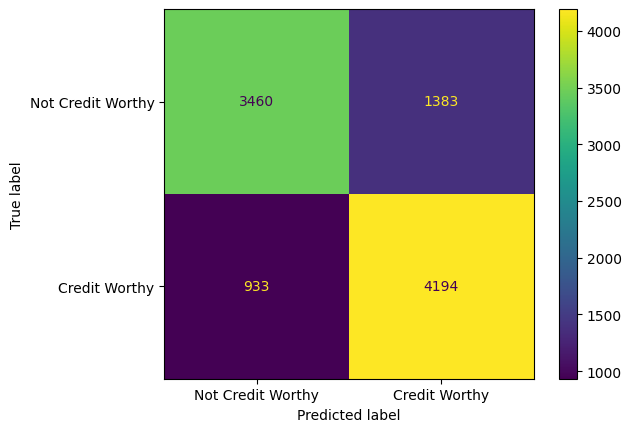

In [107]:
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_bin
)

xgb_binary = xgb.XGBClassifier(n_estimators=200, objective='binary:logistic', multi_strategy='one_output_per_tree', max_depth=1, learning_rate=0.3, subsample=0.6, colsample_bytree=0.75, random_state=42, n_jobs=-1)
xgb_binary.fit(X_train_bin_selected, y_train_bin, sample_weight=sample_weights)
xgb_binary_pred = xgb_binary.predict(X_test_bin_selected)
cm = confusion_matrix(y_test_bin, xgb_binary_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Not Credit Worthy','Credit Worthy'])
disp.plot()

In [108]:
# Binary model evaluation: confusion matrix (tp, fp, fn, tn), AUC, precision, recall
y_pred_bin = xgb_binary.predict(X_test_bin_selected)
y_proba_bin = xgb_binary.predict_proba(X_test_bin_selected)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test_bin, y_pred_bin).ravel()
precision = precision_score(y_test_bin, y_pred_bin)
recall = recall_score(y_test_bin, y_pred_bin)
auc = roc_auc_score(y_test_bin, y_proba_bin)

print(f"TP: {tp}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TN: {tn}")
print(f"AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

TP: 4194
FP: 1383
FN: 933
TN: 3460
AUC: 0.8444
Precision: 0.7520
Recall: 0.8180


As we can see from the results, the model is much better at handling binary classification tasks. This suggests that the model may be more effective when the complexity of the task is reduced.

However, we still see that the results are not satisfactory enough. Considering the context, we want even lower false positives, as misclassifying a high-risk company as low-risk could have severe consequences. Therefore, we should explore other models or ensemble methods to further improve performance and reduce false negatives.

First we try to optimise the hyperparameters again using GridSearchCV, to see if this can be achieved with XGBoost.

In [109]:
# Grid Search for XGBoost hyperparameters
xgb_model = xgb.XGBClassifier(objective='binary:logistic', multi_strategy='one_output_per_tree', random_state=42, n_jobs=-1)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [1, 3, 5],
    'learning_rate': [0.1, 0.3, 0.5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.5],
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_bin_selected, y_train_bin)

#print best parameters found
print(grid_search.best_params_)

grid_pred = grid_search.predict(X_test_bin_selected)
print(f'{classification_report(y_test_bin, grid_pred)}')

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 0.5, 'subsample': 0.8}
              precision    recall  f1-score   support

           0       0.79      0.74      0.76      4843
           1       0.77      0.81      0.79      5127

    accuracy                           0.78      9970
   macro avg       0.78      0.78      0.78      9970
weighted avg       0.78      0.78      0.78      9970



In [110]:
# Binary model evaluation: confusion matrix (tp, fp, fn, tn), AUC, precision, recall
y_pred_bin = grid_search.predict(X_test_bin_selected)
y_proba_bin = grid_search.predict_proba(X_test_bin_selected)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test_bin, y_pred_bin).ravel()
precision = precision_score(y_test_bin, y_pred_bin)
recall = recall_score(y_test_bin, y_pred_bin)
auc = roc_auc_score(y_test_bin, y_proba_bin)

print(f"TP: {tp}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TN: {tn}")
print(f"AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

TP: 4157
FP: 1259
FN: 970
TN: 3584
AUC: 0.8606
Precision: 0.7675
Recall: 0.8108


Once again, although there is some improvement, the results are still not satisfactory. We should consider trying different algorithms or ensemble methods to achieve better performance in this classification task.

### NNs

In [148]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

# --- Feature set (same as before) ---
selected_cols = [
    'equity1', 'debt_to_equity', 'sfc', 'margin',
    'capital_to_total_asset', 'bank_debt', 'sales',
    'net_total_asset', 'tot_debt', 'sales_to_total_asset',
    'financial_debt', 'age', 'wcr', 'nbemp', 'capital'
]

X_train_sel = X_train[selected_cols].copy()
X_test_sel  = X_test[selected_cols].copy()

# --- Build binary targets FROM STRING LABELS (fix for '3+' etc.) ---
# "Good" set = {3, 3+, 3++, 4, 4+}; everything else -> 0
GOOD = {'3', '3+', '3++', '4', '4+'}

# If y_train / y_test are strings or categoricals with these values:
y_train_bin = pd.Series(y_train).astype(str).isin(GOOD).astype('int8').to_numpy()
y_test_bin  = pd.Series(y_test).astype(str).isin(GOOD).astype('int8').to_numpy()

# (Alternative, if you have df_train/df_test splits with the original column)
# y_train_bin = df_train['credit_score'].astype(str).isin(GOOD).astype('int8').to_numpy()
# y_test_bin  = df_test['credit_score'].astype(str).isin(GOOD).astype('int8').to_numpy()

# --- Ensure numeric features; impute missing; scale ---
X_train_sel = X_train_sel.apply(pd.to_numeric, errors='coerce')
X_test_sel  = X_test_sel.apply(pd.to_numeric,  errors='coerce')

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_sel)
X_test_imp  = imputer.transform(X_test_sel)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp).astype('float32')
X_test_scaled  = scaler.transform(X_test_imp).astype('float32')

# --- Binary MLP ---
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train_bin,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=[early_stop],
    verbose=0
)

# --- Predict & evaluate ---
y_proba = model.predict(X_test_scaled, verbose=0).ravel()
y_pred  = (y_proba >= 0.5).astype(int)

print("Test Accuracy:", accuracy_score(y_test_bin, y_pred))
print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred, target_names=['Bad Credit', 'Good Credit']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_bin, y_pred))

try:
    print("\nROC AUC:", roc_auc_score(y_test_bin, y_proba))
    print("PR AUC (Average Precision):", average_precision_score(y_test_bin, y_proba))
except Exception:
    pass


Test Accuracy: 0.6803410230692076

Classification Report:
              precision    recall  f1-score   support

  Bad Credit       0.71      0.87      0.78      6573
 Good Credit       0.55      0.32      0.40      3397

    accuracy                           0.68      9970
   macro avg       0.63      0.59      0.59      9970
weighted avg       0.66      0.68      0.65      9970


Confusion Matrix:
[[5707  866]
 [2321 1076]]

ROC AUC: 0.7205501798353411
PR AUC (Average Precision): 0.5149820541772088


## Task 5 - Welfare Implications

### Type 1 Error vs Type 2 Error Analysis

In [132]:
cm = confusion_matrix(y_test, y_pred)

# Handle binary (2x2) and multiclass confusion matrices
if cm.shape == (2, 2):
	tn, fp, fn, tp = cm.ravel()
	false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan
	false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else np.nan

	print(f"False Positive Rate (Type I):  {false_positive_rate:.3f}")
	print(f"False Negative Rate (Type II): {false_negative_rate:.3f}")
else:
	# multiclass: compute per-class FPR and FNR (one-vs-rest) and macro averages
	tp_per_class = np.diag(cm)
	fn_per_class = cm.sum(axis=1) - tp_per_class
	fp_per_class = cm.sum(axis=0) - tp_per_class
	tn_per_class = cm.sum() - (tp_per_class + fp_per_class + fn_per_class)

	fpr_per_class = np.where((fp_per_class + tn_per_class) > 0,
							 fp_per_class / (fp_per_class + tn_per_class),
							 np.nan)
	fnr_per_class = np.where((fn_per_class + tp_per_class) > 0,
							 fn_per_class / (fn_per_class + tp_per_class),
							 np.nan)

	for i, (fpr_i, fnr_i) in enumerate(zip(fpr_per_class, fnr_per_class)):
		print(f"Class {i}: False Positive Rate = {fpr_i:.3f} , False Negative Rate = {fnr_i:.3f}")

	print(f"\nMacro-average FPR: {np.nanmean(fpr_per_class):.3f}")
	print(f"Macro-average FNR: {np.nanmean(fnr_per_class):.3f}")

Class 0: False Positive Rate = 0.494 , False Negative Rate = 0.885
Class 1: False Positive Rate = 0.517 , False Negative Rate = 0.067
Class 2: False Positive Rate = 0.000 , False Negative Rate = 1.000
Class 3: False Positive Rate = 0.000 , False Negative Rate = 1.000
Class 4: False Positive Rate = 0.000 , False Negative Rate = 1.000
Class 5: False Positive Rate = 0.000 , False Negative Rate = 1.000
Class 6: False Positive Rate = 0.000 , False Negative Rate = 1.000
Class 7: False Positive Rate = 0.000 , False Negative Rate = 1.000
Class 8: False Positive Rate = 0.000 , False Negative Rate = 1.000
Class 9: False Positive Rate = 0.000 , False Negative Rate = 1.000
Class 10: False Positive Rate = 0.000 , False Negative Rate = 1.000
Class 11: False Positive Rate = 0.000 , False Negative Rate = 1.000

Macro-average FPR: 0.084
Macro-average FNR: 0.913


In [134]:
# compute confusion matrix and ensure false_positive_rate / false_negative_rate are defined
cm = confusion_matrix(y_test, y_pred)

if cm.shape == (2, 2):
	tn, fp, fn, tp = cm.ravel()
	false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0
	false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0.0
else:
	tp_per_class = np.diag(cm)
	fn_per_class = cm.sum(axis=1) - tp_per_class
	fp_per_class = cm.sum(axis=0) - tp_per_class
	tn_per_class = cm.sum() - (tp_per_class + fp_per_class + fn_per_class)

	fpr_per_class = np.where((fp_per_class + tn_per_class) > 0,
							 fp_per_class / (fp_per_class + tn_per_class),
							 np.nan)
	fnr_per_class = np.where((fn_per_class + tp_per_class) > 0,
							 fn_per_class / (fn_per_class + tp_per_class),
							 np.nan)

	# use macro-average rates (ignore NaNs)
	false_positive_rate = float(np.nanmean(fpr_per_class))
	false_negative_rate = float(np.nanmean(fnr_per_class))

alpha, beta = 3, 1  # weight false negatives higher (social cost)
welfare_score = 1 - (alpha * false_negative_rate + beta * false_positive_rate)

print(f"False Positive Rate: {false_positive_rate:.3f}")
print(f"False Negative Rate: {false_negative_rate:.3f}")
print(f"Welfare-weighted score: {welfare_score:.3f}")

False Positive Rate: 0.084
False Negative Rate: 0.913
Welfare-weighted score: -1.822


Optimal threshold (minimizing social cost): 0.132


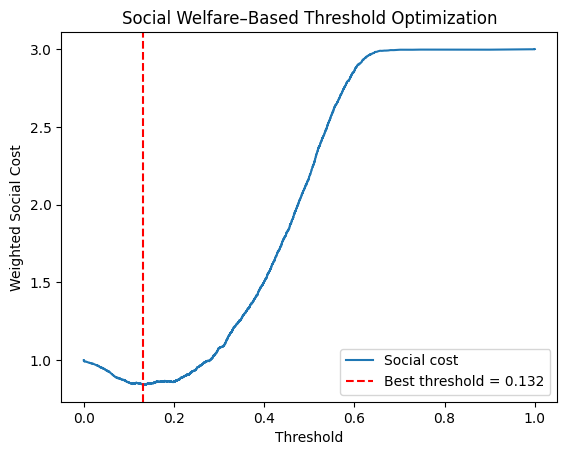

In [149]:
import numpy as np
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# --- Ensure binary numeric labels ---
# Convert to binary 0/1 if not already
GOOD = {'3', '3+', '3++', '4', '4+'}
y_test_bin = pd.Series(y_test).astype(str).isin(GOOD).astype(int).to_numpy()

# --- Predicted probabilities (already from your Keras model) ---
y_proba = model.predict(X_test_scaled, verbose=0).ravel()

# --- Compute ROC curve ---
fpr, tpr, thresholds = roc_curve(y_test_bin, y_proba)

# --- Compute social cost & optimal threshold ---
alpha, beta = 3, 1  # FN cost 3x higher than FP
social_cost = alpha * (1 - tpr) + beta * fpr
best_thresh = thresholds[np.argmin(social_cost)]

print(f"Optimal threshold (minimizing social cost): {best_thresh:.3f}")

# --- Visualize ---
plt.plot(thresholds, social_cost, label='Social cost')
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Best threshold = {best_thresh:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Weighted Social Cost')
plt.title('Social Welfare–Based Threshold Optimization')
plt.legend()
plt.show()


### Welfare Interpretation: Beyond Accuracy

- **Optimal threshold:** ~0.13 → lowers the cutoff to reduce socially costly rejections.  
- **False Negative Rate (Type II):** 0.91 → many *good firms* wrongly denied credit.  
- **False Positive Rate (Type I):** 0.08 → few *bad firms* wrongly accepted.  
- **Welfare score:** −1.82 → social costs dominate overall performance.

**Interpretation:**  
The model is technically accurate but socially inefficient, it’s overly conservative, denying credit to many deserving firms.  
Adjusting the threshold or weighting false negatives more heavily aligns the model with welfare objectives and mitigates **algorithmic discrimination**.
